# EnergyScope Results Analysis - Norte Amazonica

Optimisation **EnergyScope MultiCell** de la region *Norte Amazonica* (Bolivie), represented by **5 cellules clusterisees** (C1-C5) qui preservent les differences de connectivite au reseau, de densite de population et d'infrastructure existante.

**Research question** : *how should this isolated region plan its energy transition under different demand and transition scenarios ?*

This notebook analyses **one scenario** at a time (defined below) and is designed to be **re-run as-is on another scenario** (e.g. `reality` vs `sufficiency`) afin de comparer les strategies d'approvisionnement.

## Plan
1. Executive summary - corrected indicators
2. **End-use demand** - what drives the system
3. **Mix d'approvisionnement electrique** - d'ou vient reellement l'electricite
4. **Autonomy & imports** - external dependence by region
5. Costs - breakdown + intensity (EUR/MWh)
6. Carbon footprint (GWP) + intensity
7. Stockage
8. Curtailment & flexibility
9. Inter-regional exchanges
10. Hourly profiles - electric dispatch vs demand
11. Synthese

---
**Units**: costs in M€/year . energy in GWh/year . capacity in GW . GWP in kt CO2-eq/year

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')

In [81]:
# ============================================================================
#  CONFIGURATION  -  change SCENARIO to analyse / compare another run
# ============================================================================
ROOT     = Path('case_studies/C1_C2_C3_C4_C5')
SCENARIO  = 'norte_amazonia_sufficiency_2025'          # scenario without infrastructure (phase 1)
SCENARIO_2 = 'norte_amazonia_sufficiency_2025_phase2'  # comparison scenario (phase 2)

BASE   = ROOT / SCENARIO / 'outputs'
BASE_2 = ROOT / SCENARIO_2 / 'outputs'
REG    = BASE_2 / 'regional_results'
HOURLY = BASE_2 / 'hourly_results'

REGIONS = ['C1', 'C2', 'C3', 'C4', 'C5']
# Human-readable labels (fill in with the actual cluster geography)
REGION_LABELS = {r: r for r in REGIONS}

EPS = 1e-6   # seuil "non nul"

# -- Storage technologies (to exclude from production mixes) -----------------
STORAGE_TECHS = {'BATT_LI', 'BATT_HS', 'CAES', 'PHS', 'DAM_STORAGE', 'TS_DEC_HP_ELEC',
                 'TS_HIGH_TEMP', 'GAS_STORAGE', 'H2_STORAGE', 'DIESEL_STORAGE',
                 'LPG_STORAGE', 'GASOLINE_STORAGE', 'JET_FUEL_STORAGE', 'LNG_STORAGE',
                 'AMMONIA_STORAGE', 'METHANOL_STORAGE', 'CO2_STORAGE'}

# -- Renewable / fossil / import classification for the electricity vector ----
RENEW_ELEC  = {'PV_UTILITY', 'PV_ROOFTOP', 'PV_HS', 'WIND_ONSHORE', 'WIND_OFFSHORE',
               'HYDRO_DAM', 'HYDRO_RIVER', 'TIDAL_STREAM', 'TIDAL_RANGE', 'WAVE',
               'GEOTHERMAL', 'BIOMASS_TO_POWER', 'ST_BIOMASS', 'ST_SNG'}
FOSSIL_ELEC = {'GENSET_DIESEL', 'HS_DIESEL', 'OCGT', 'CCGT', 'CCGT_AMMONIA',
               'COAL_US', 'COAL_IGCC', 'NUCLEAR', 'NUCLEAR_SMR'}
IMPORT_ELEC = {'ELECTRICITY'}   # la ressource ELECTRICITY = import depuis l'exterieur

# -- Short technology names --------------------------------------------------
TECH_LABELS = {
    'PV_UTILITY': 'PV utility', 'PV_ROOFTOP': 'PV rooftop', 'PV_HS': 'PV household',
    'WIND_ONSHORE': 'Onshore wind', 'HYDRO_DAM': 'Hydro dam', 'HYDRO_RIVER': 'Run-of-river hydro',
    'GEOTHERMAL': 'Geothermal', 'BIOMASS_TO_POWER': 'Biomass power',
    'ST_SNG': 'SNG turbine', 'ST_BIOMASS': 'Biomass turbine',
    'GENSET_DIESEL': 'Diesel genset', 'HS_DIESEL': 'Household diesel',
    'OCGT': 'OCGT', 'CCGT': 'CCGT', 'ELECTRICITY': 'Electricity import',
    'BATT_LI': 'Li-ion battery', 'BATT_HS': 'Household battery',
}
def get_label(t): return TECH_LABELS.get(t, t)

# -- Technology colours (electricity mix) ------------------------------------
TECH_COLORS = {
    'PV_UTILITY':        "#E9B081",
    'PV_ROOFTOP':        "#CE8A68",
    'PV_HS':             "#FCDBB7",
    'WIND_ONSHORE':      '#52A8D8',
    'HYDRO_DAM':         '#1B5E8C',
    'HYDRO_RIVER':       "#3D83B1",
    'GEOTHERMAL':        '#A0789E',
    'BIOMASS_TO_POWER':  '#6BA888',
    'ST_BIOMASS':        '#539C78',
    'ST_SNG':            '#8EC4A8',
    'GENSET_DIESEL':     '#7B8FA0',
    'HS_DIESEL':         '#A8B8C4',
    'OCGT':              '#8BB4C8',
    'CCGT':              '#5F8FA8',
    'ELECTRICITY':       "#56A0F5",
    'BATT_LI':           '#9370DB',
    'BATT_HS':           '#6A0DAD',
}
def get_color(t): return TECH_COLORS.get(t, '#B0C4D4')

# -- End-uses (demand): labels + colours -------------------------------------
EUD_LABELS = {
    'COOKING': 'Cooking', 'ELECTRICITY': 'Direct electricity',
    'SPACE_COOLING': 'Space cooling', 'FOOD_PRESERVATION': 'Refrigeration',
    'HEAT_LOW_T_DECEN': 'Low-T heat', 'LIGHTING_R_C': 'Res./com. lighting',
    'LIGHTING_P': 'Public lighting', 'MECHANICAL_ENERGY_COMM': 'Mech. commerce',
    'MECHANICAL_ENERGY_IND': 'Mech. industry',
    'MECHANICAL_ENERGY_FIX_AGR': 'Mech. agriculture',
    'MECHANICAL_ENERGY_FISH_OTHERS': 'Mech. fishing',
}
EUD_COLORS = {
    'COOKING':                      "#DA7C7C",
    'ELECTRICITY':                  "#3A81C0",
    'SPACE_COOLING':                '#74C4D8',
    'FOOD_PRESERVATION':            "#6688BE",
    'HEAT_LOW_T_DECEN':             '#D48C60',
    'LIGHTING_R_C':                 '#C8A84A',
    'LIGHTING_P':                   '#A89050',
    'MECHANICAL_ENERGY_COMM':       '#7B6DC0',
    'MECHANICAL_ENERGY_IND':        '#524A98',
    'MECHANICAL_ENERGY_FIX_AGR':    '#6A9E7A',
    'MECHANICAL_ENERGY_FISH_OTHERS':'#4A9E98',
}
def eud_label(l): return EUD_LABELS.get(l, l)
def eud_color(l): return EUD_COLORS.get(l, '#B0C4D4')

print(f'Configuration loaded  OK')
print(f'  scenario 1 = {SCENARIO}')
print(f'  scenario 2 = {SCENARIO_2}')

Configuration loaded  OK
  scenario 1 = norte_amazonia_sufficiency_2025
  scenario 2 = norte_amazonia_sufficiency_2025_phase2


In [82]:
# -- Chargement centralise d'un scenario -------------------------------------
def num(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

def load_scenario(base):
    reg = base / 'regional_results'
    D = {}
    D['total_cost'] = pd.read_csv(reg / 'TotalCost.csv', sep=';')
    D['assets']     = num(pd.read_csv(reg / 'Assets.csv', sep=';'), ['F', 'F_year'])
    D['cost']       = num(pd.read_csv(reg / 'Cost_breakdown.csv', sep=';'), ['C_inv', 'C_maint', 'C_op'])
    D['gwp']        = num(pd.read_csv(reg / 'Gwp_breakdown.csv', sep=';'), ['GWP_constr', 'GWP_op', 'CO2_net'])
    D['curt']       = num(pd.read_csv(reg / 'Curt.csv', sep=';'), ['Curt'])
    D['sto']        = num(pd.read_csv(reg / 'Sto_assets.csv', sep=';'), ['F', 'Year_energy_flux', 'Losses'])
    D['exch']       = num(pd.read_csv(reg / 'Exchanges_year.csv', sep=';'), ['Exchanges_year', 'Transfer_capacity', 'Utilization_factor'])
    D['res']        = num(pd.read_csv(reg / 'Resources.csv', sep=';'),
                          ['R_year_local', 'R_year_exterior', 'R_year_import', 'R_year_export'])
    D['yb']         = pd.read_csv(reg / 'Year_balance.csv', sep=';')
    D['objective']  = pd.read_csv(base / 'Objective.csv', sep=';')
    D['solve']      = pd.read_csv(base / 'Solve_info.csv', sep=';')
    return D

D = load_scenario(BASE_2)
total_cost = D['total_cost']; total_cost = total_cost[total_cost['Regions'].isin(REGIONS)].copy()
assets, cost_reg, gwp_reg = D['assets'], D['cost'], D['gwp']
curt_reg, sto_reg, exch_reg, res_reg = D['curt'], D['sto'], D['exch'], D['res']
yb, objective, solve_info = D['yb'], D['objective'], D['solve']

# -- Year_balance helpers ----------------------------------------------------
def layer(yb, lay):
    '''Return (Regions, Elements, val) for a given energy layer.'''
    d = yb[['Regions', 'Elements', lay]].copy()
    d[lay] = pd.to_numeric(d[lay], errors='coerce').fillna(0)
    return d.rename(columns={lay: 'val'})

def elec_supply(yb, regions):
    '''Mix d'approvisionnement electrique : productions positives, hors stockage.'''
    d = layer(yb, 'ELECTRICITY')
    d = d[(d['val'] > EPS) & (~d['Elements'].isin(STORAGE_TECHS)) & (d['Regions'].isin(regions))]
    return d

def eud_demand(yb, regions):
    '''Useful demand by end-use and region (positive values, GWh/year).'''
    eu = yb[yb['Elements'] == 'END_USES'].set_index('Regions')
    out = {}
    for lay in EUD_LABELS:
        if lay in eu.columns:
            out[lay] = pd.to_numeric(eu[lay], errors='coerce').abs()
    dem = pd.DataFrame(out).reindex(regions).fillna(0)
    return dem.loc[:, dem.sum() > 1e-4]

print('Data loaded  OK')
print(f"  regions       : {sorted(yb['Regions'].unique())}")
print(f"  balance rows  : {len(yb)}   |   techs/resources : {yb['Elements'].nunique()}")

Data loaded  OK
  regions       : ['C1', 'C2', 'C3', 'C4', 'C5']
  balance rows  : 1520   |   techs/resources : 304


---
## 1. Executive summary

Indicateurs cles **corriges**. Attention : contrairement a une somme naive des `F_year` (qui agrege stockage, reseau et conversions et n'a pas de sens physique), la production electrique et la demande utile sont ici calculees a partir du **bilan annuel par vecteur** (`Year_balance`).

In [83]:
obj_value      = float(objective.iloc[0, -1])
solve_time_s   = float(solve_info[solve_info.iloc[:, 0].astype(str).str.contains('solve_elapsed', na=False)].iloc[0, 1])
total_sys_cost = total_cost['TotalCost'].sum()

# Production electrique reelle (vecteur ELECTRICITY, hors stockage)
es = elec_supply(yb, REGIONS)
elec_total   = es['val'].sum()
elec_import  = es[es['Elements'].isin(IMPORT_ELEC)]['val'].sum()
elec_local   = elec_total - elec_import
elec_renew   = es[es['Elements'].isin(RENEW_ELEC)]['val'].sum()

# Demande utile totale (tous usages finaux)
dem = eud_demand(yb, REGIONS)
demande_totale = dem.values.sum()

# Emissions : GWP operationnel (coherent avec section 6 et synthese)
gwp_op_tot = pd.to_numeric(gwp_reg['GWP_op'], errors='coerce').fillna(0).sum()

# Technologies reellement deployees (capacite F > 0)
af = assets[assets['F'] > EPS]
n_active = af['Technologies'].nunique()

line = '=' * 60
print(line)
print(f'   EXECUTIVE SUMMARY - {SCENARIO}')
print(line)
print(f'  Total system cost             : {total_sys_cost:>9.2f} M€/year')
print(f'  Useful demand served          : {demande_totale:>9.1f} GWh/year')
print(f'  Electricity production        : {elec_total:>9.1f} GWh/year')
print(f'     . local                     : {elec_local:>9.1f} GWh/year ({elec_local/elec_total*100:4.1f} %)')
print(f'     . imported                  : {elec_import:>9.1f} GWh/year ({elec_import/elec_total*100:4.1f} %)')
print(f'     . renewable (local)         : {elec_renew:>9.1f} GWh/year ({elec_renew/elec_total*100:4.1f} %)')
print(f'  Operational GWP emissions     : {gwp_op_tot:>9.2f} kt CO2-eq/year')
print(f'  Average electricity cost      : {total_sys_cost*1000/demande_totale:>9.1f} EUR/MWh utile')
print(f'  Deployed technologies         : {n_active:>9d}')
print(f'  Solver elapsed time           : {solve_time_s:>9.1f} s')
print('-' * 60)
print('  Cost breakdown by region      :')
for _, r in total_cost.sort_values('TotalCost', ascending=False).iterrows():
    pct = r['TotalCost'] / total_sys_cost * 100
    bar = '#' * int(pct / 2)
    print(f'    {r["Regions"]}  {r["TotalCost"]:>6.2f} M-euro  {bar} {pct:4.1f}%')
print(line)

   EXECUTIVE SUMMARY - norte_amazonia_sufficiency_2025
  Total system cost             :     24.18 M€/year
  Useful demand served          :     187.3 GWh/year
  Electricity production        :     142.5 GWh/year
     . local                     :     129.5 GWh/year (90.9 %)
     . imported                  :      13.0 GWh/year ( 9.1 %)
     . renewable (local)         :     127.4 GWh/year (89.3 %)
  Operational GWP emissions     :     48.18 kt CO2-eq/year
  Average electricity cost      :     129.1 EUR/MWh utile
  Deployed technologies         :        35
  Solver elapsed time           :      44.0 s
------------------------------------------------------------
  Cost breakdown by region      :
    C3   10.97 M-euro  ###################### 45.4%
    C5    6.82 M-euro  ############## 28.2%
    C4    3.72 M-euro  ####### 15.4%
    C1    2.39 M-euro  ####  9.9%
    C2    0.28 M-euro    1.2%


---
## 2. End-use demand

C'est le **point de depart** de la these : la strategie d'approvisionnement optimale depend directement de la structure de la demande. On lit ici la demande *utile* (sortie de la ligne `END_USES` du bilan), independamment du vecteur qui la satisfait.

> A `reality` vs `sufficiency` scenario comparison maps directly onto this chart: same code, different `SCENARIO`.

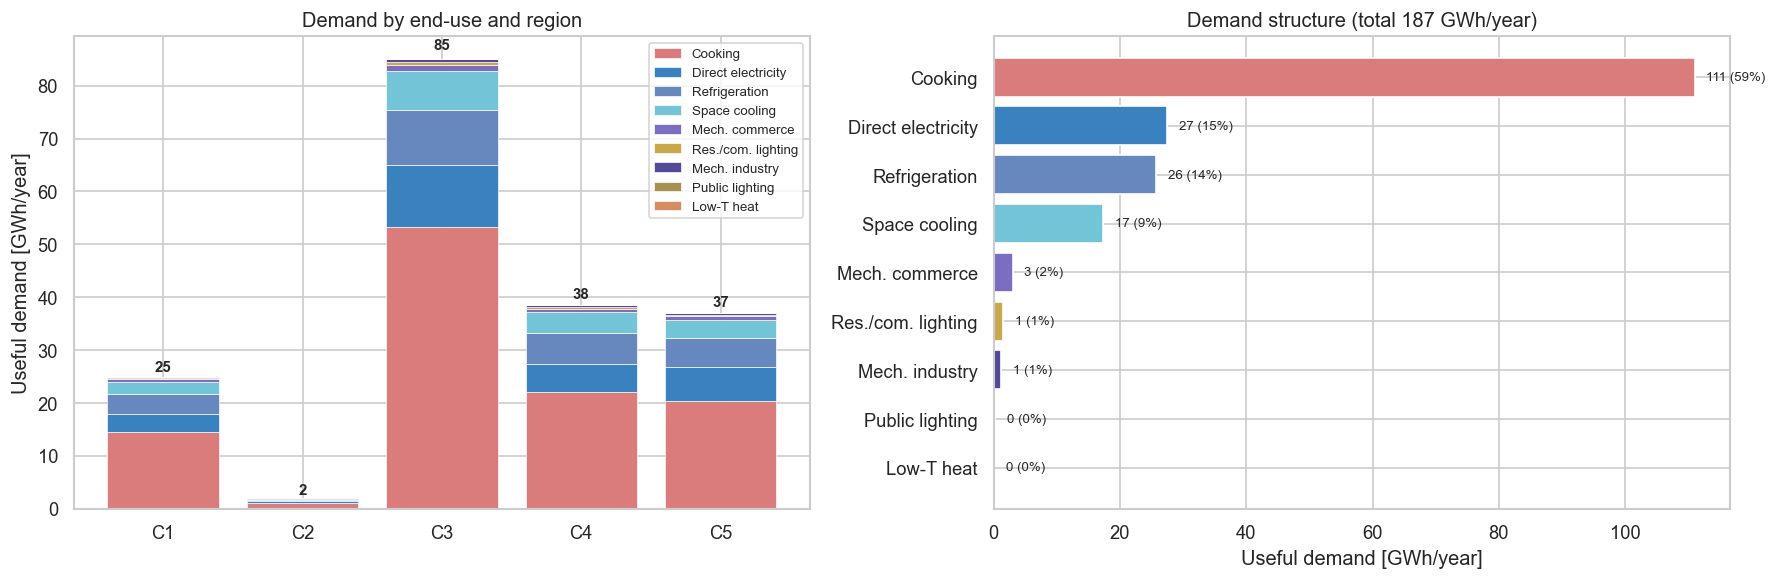

Useful demand by end-use and region [GWh/year]:
         COOKING  ELECTRICITY  SPACE_COOLING  FOOD_PRESERVATION  HEAT_LOW_T_DECEN  LIGHTING_R_C  LIGHTING_P  MECHANICAL_ENERGY_COMM  MECHANICAL_ENERGY_IND
Regions                                                                                                                                                   
C1         14.41         3.49           2.23               3.84               0.0          0.22        0.03                    0.44                   0.18
C2          1.07         0.30           0.19               0.28               0.0          0.02        0.00                    0.03                   0.01
C3         53.21        11.85           7.34              10.33               0.0          0.60        0.08                    1.21                   0.49
C4         22.02         5.30           3.99               5.83               0.0          0.33        0.04                    0.67                   0.26
C5         20.28      

In [84]:
dem = eud_demand(yb, REGIONS)
dem_sorted = dem[dem.sum().sort_values(ascending=False).index]   # usages dominants d'abord

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# -- (a) demand by end-use and region ---------------------------------------
ax = axes[0]
bottom = np.zeros(len(REGIONS)); x = np.arange(len(REGIONS))
for lay in dem_sorted.columns:
    ax.bar(x, dem_sorted[lay].values, bottom=bottom, label=eud_label(lay),
           color=eud_color(lay), edgecolor='white', linewidth=.4)
    bottom += dem_sorted[lay].values
for xi, tot in zip(x, dem.sum(axis=1).values):
    ax.text(xi, tot + tot*0.01 + 0.3, f'{tot:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([REGION_LABELS[r] for r in REGIONS])
ax.set_ylabel('Useful demand [GWh/year]')
ax.set_title('Demand by end-use and region')
ax.legend(fontsize=8, loc='upper right')

# -- (b) relative structure (share per use, all regions) --------------------
ax = axes[1]
shares = dem.sum().sort_values(ascending=True)
ax.barh(range(len(shares)), shares.values, color=[eud_color(l) for l in shares.index], edgecolor='white')
ax.set_yticks(range(len(shares))); ax.set_yticklabels([eud_label(l) for l in shares.index])
tot = shares.sum()
for i, v in enumerate(shares.values):
    ax.text(v + tot*0.01, i, f'{v:.0f} ({v/tot*100:.0f}%)', va='center', fontsize=8)
ax.set_xlabel('Useful demand [GWh/year]')
ax.set_title(f'Demand structure (total {tot:.0f} GWh/year)')
plt.tight_layout(); plt.show()

print('Useful demand by end-use and region [GWh/year]:')
print(dem.round(2).to_string())

---
## 3. Mix d'approvisionnement electrique

D'ou vient **reellement** l'electricite, par region et au total. Lecture directe du vecteur `ELECTRICITY` du bilan (productions positives, stockage exclu). L'**import** (ressource `ELECTRICITY`) est distingue de la production locale.

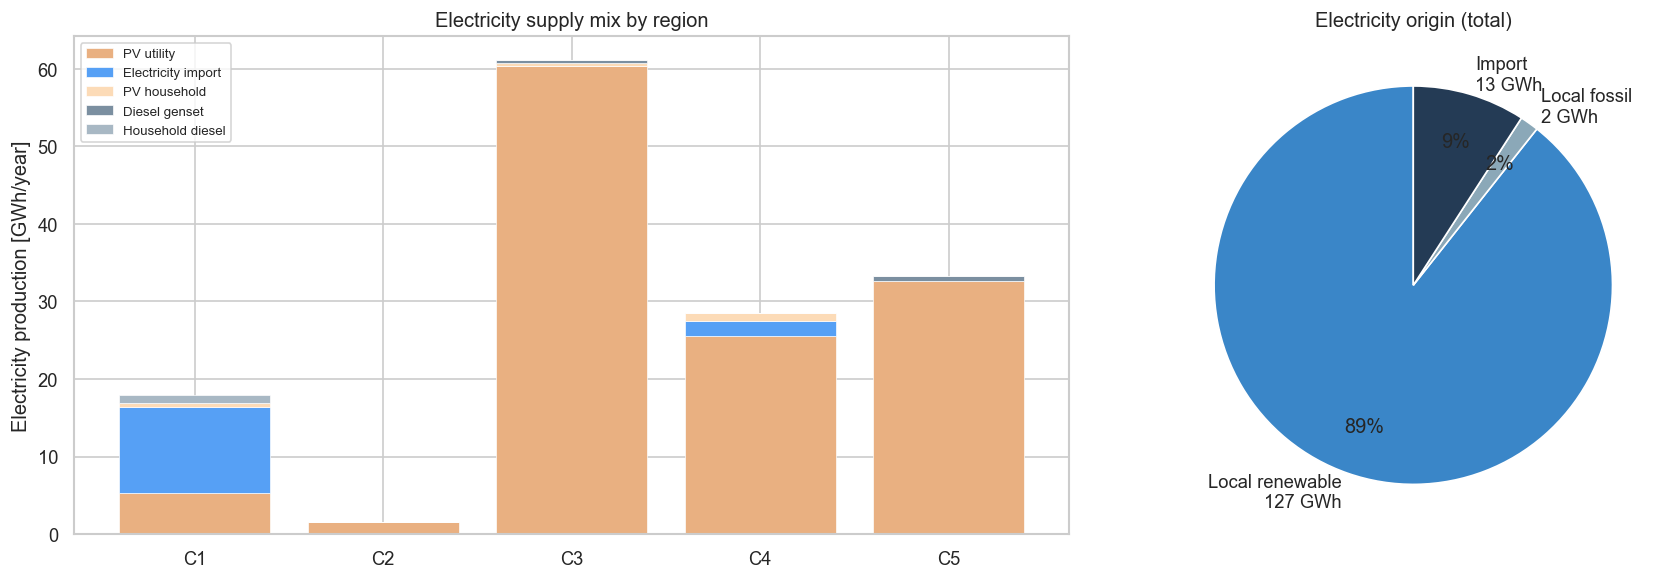

Electricity mix by region [GWh/year]:
Elements  PV_UTILITY  ELECTRICITY  PV_HS  GENSET_DIESEL  HS_DIESEL
Regions                                                           
C1              5.27        11.09   0.55           0.00       1.02
C2              1.52         0.00   0.06           0.00       0.01
C3             60.34         0.00   0.35           0.44       0.02
C4             25.60         1.94   0.97           0.00       0.03
C5             32.69         0.00   0.00           0.65       0.00


In [85]:
es = elec_supply(yb, REGIONS)
pivot = es.pivot_table(index='Regions', columns='Elements', values='val', aggfunc='sum', fill_value=0).reindex(REGIONS).fillna(0)
pivot = pivot[pivot.sum().sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1.4, 1]})

# -- (a) mix by region ------------------------------------------------------
ax = axes[0]
bottom = np.zeros(len(REGIONS)); x = np.arange(len(REGIONS))
for tech in pivot.columns:
    ax.bar(x, pivot[tech].values, bottom=bottom, label=get_label(tech),
           color=get_color(tech), edgecolor='white', linewidth=.4)
    bottom += pivot[tech].values
ax.set_xticks(x); ax.set_xticklabels([REGION_LABELS[r] for r in REGIONS])
ax.set_ylabel('Electricity production [GWh/year]')
ax.set_title('Electricity supply mix by region')
ax.legend(fontsize=8, loc='upper left')

# -- (b) renewable / fossil / import split (aggregated) ---------------------
ax = axes[1]
cat = {'Local renewable': es[es['Elements'].isin(RENEW_ELEC)]['val'].sum(),
       'Local fossil':      es[es['Elements'].isin(FOSSIL_ELEC)]['val'].sum(),
       'Import':             es[es['Elements'].isin(IMPORT_ELEC)]['val'].sum()}
cat = {k: v for k, v in cat.items() if v > EPS}
cols = {'Local renewable': '#3A86C8', 'Local fossil': '#8BA8B8', 'Import': '#243B55'}
ax.pie(cat.values(), labels=[f'{k}\n{v:.0f} GWh' for k, v in cat.items()],
       colors=[cols[k] for k in cat], autopct='%1.0f%%', startangle=90, pctdistance=0.75)
ax.set_title('Electricity origin (total)')
plt.tight_layout(); plt.show()

print('Electricity mix by region [GWh/year]:')
print(pivot.round(2).to_string())

---
## 4. Autonomy & import dependence

Question centrale pour une region **isolee** : quelle part de l'energie est produite localement vs importee de l'exterieur (electricite du Bresil/SIN, diesel, GPL...) ? On combine l'import d'electricite et les ressources fossiles importees (`Resources.csv`).

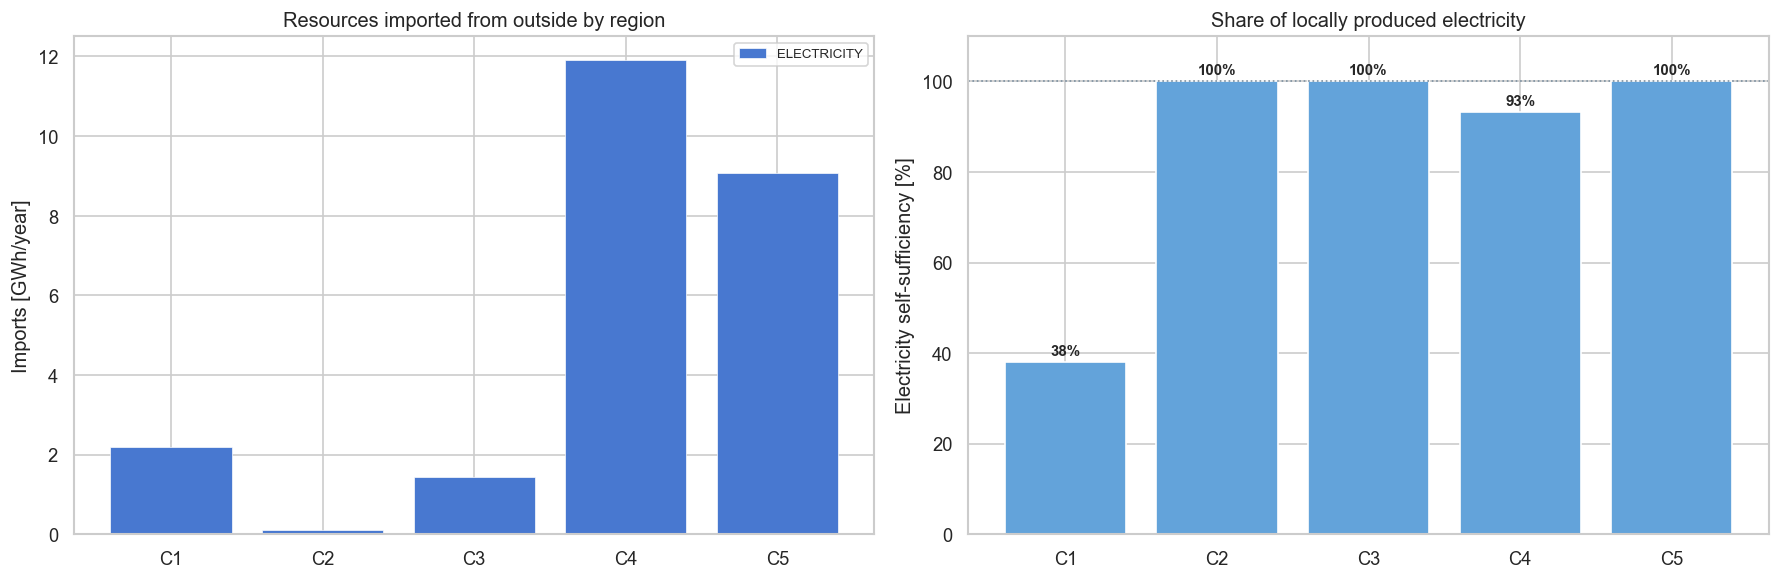

Imports by resource and region [GWh/year]:
Resources  ELECTRICITY
Regions               
C1                2.18
C2                0.10
C3                1.45
C4               11.91
C5                9.08


In [86]:
r = res_reg[res_reg['Regions'].isin(REGIONS)].copy()
imp = r[r['R_year_import'] > EPS].pivot_table(index='Regions', columns='Resources',
        values='R_year_import', aggfunc='sum', fill_value=0).reindex(REGIONS).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# -- (a) resource imports by region -----------------------------------------
ax = axes[0]
imp_s = imp[imp.sum().sort_values(ascending=False).index] if not imp.empty else imp
bottom = np.zeros(len(REGIONS)); x = np.arange(len(REGIONS))
palette = sns.color_palette('muted', max(len(imp_s.columns), 1))
for c, col in zip(imp_s.columns, palette):
    ax.bar(x, imp_s[c].values, bottom=bottom, label=c, color=col, edgecolor='white', linewidth=.4)
    bottom += imp_s[c].values
ax.set_xticks(x); ax.set_xticklabels([REGION_LABELS[rr] for rr in REGIONS])
ax.set_ylabel('Imports [GWh/year]')
ax.set_title('Resources imported from outside by region')
ax.legend(fontsize=8)

# -- (b) electricity self-sufficiency rate by region ------------------------
ax = axes[1]
es = elec_supply(yb, REGIONS)
loc = es[~es['Elements'].isin(IMPORT_ELEC)].groupby('Regions')['val'].sum().reindex(REGIONS).fillna(0)
imp_el = es[es['Elements'].isin(IMPORT_ELEC)].groupby('Regions')['val'].sum().reindex(REGIONS).fillna(0)
tot_el = (loc + imp_el).replace(0, np.nan)
auto = (loc / tot_el * 100).fillna(0)
bars = ax.bar(x, auto.values, color="#63A3DA", edgecolor='white')
for b, v in zip(bars, auto.values):
    ax.text(b.get_x()+b.get_width()/2, v+1.5, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')
ax.axhline(100, color='#7B8FA0', ls=':', lw=1)
ax.set_xticks(x); ax.set_xticklabels([REGION_LABELS[rr] for rr in REGIONS])
ax.set_ylabel('Electricity self-sufficiency [%]'); ax.set_ylim(0, 110)
ax.set_title('Share of locally produced electricity')
plt.tight_layout(); plt.show()

print('Imports by resource and region [GWh/year]:')
print((imp.round(2).to_string() if not imp.empty else '  no imports'))

---
## 5. Costs

Decomposition investissement / maintenance / operation, et surtout **intensite de cout** (EUR/MWh de demande utile servie) par region - l'indicateur qui relie directement la strategie d'approvisionnement a la question de recherche.

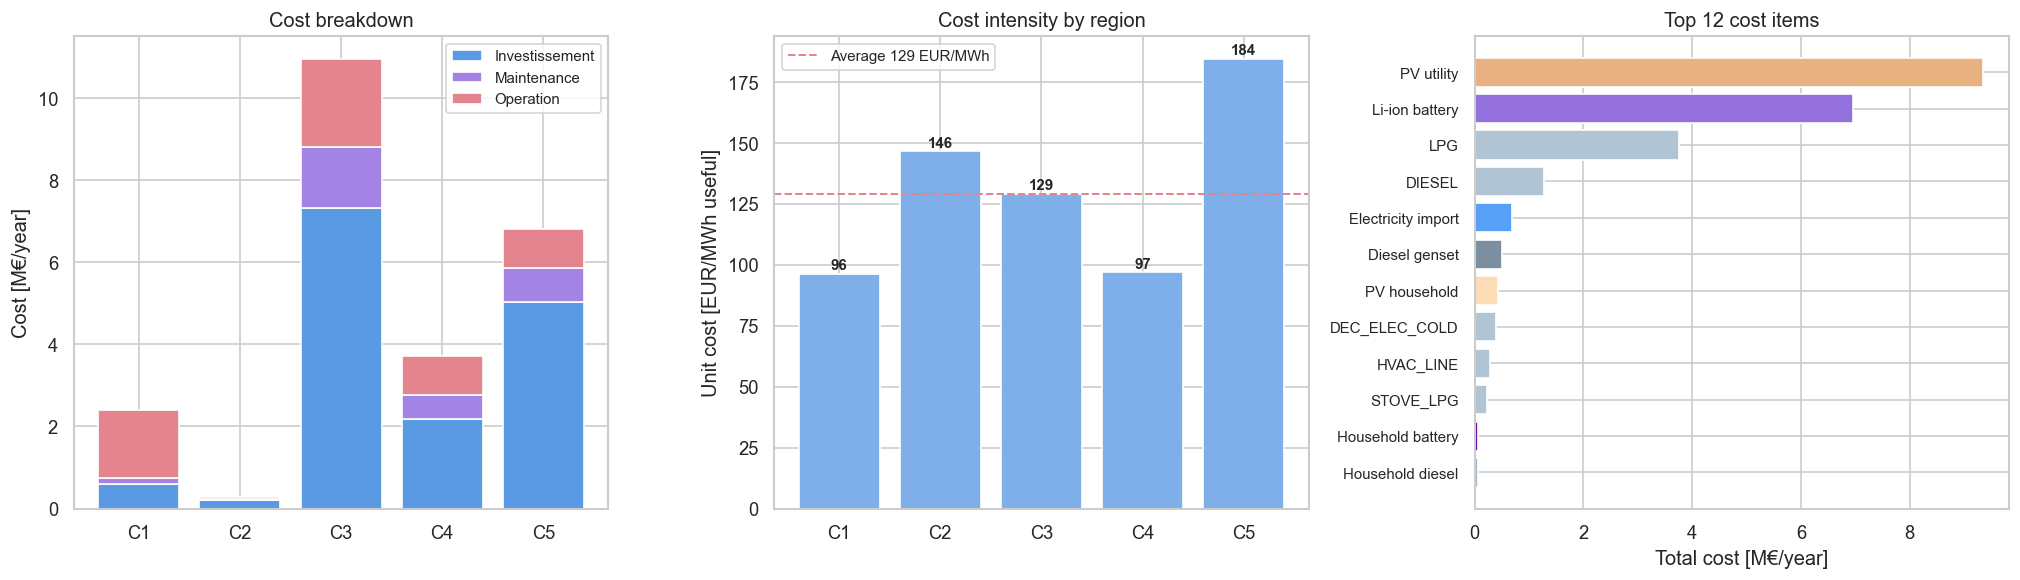

Costs by region [M€/year]:
         C_inv  C_maint  C_op  Total
Regions                             
C1        0.60     0.15  1.64   2.39
C2        0.20     0.03  0.05   0.28
C3        7.33     1.50  2.15  10.97
C4        2.18     0.60  0.94   3.72
C5        5.05     0.82  0.96   6.82


In [87]:
c = cost_reg[cost_reg['Regions'].isin(REGIONS)].copy()
for col in ['C_inv', 'C_maint', 'C_op']:
    c[col] = c[col].fillna(0)
by_reg = c.groupby('Regions')[['C_inv', 'C_maint', 'C_op']].sum().reindex(REGIONS).fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# -- (a) breakdown by region ------------------------------------------------
ax = axes[0]
x = np.arange(len(REGIONS)); bottom = np.zeros(len(REGIONS))
parts = [('C_inv', "#5A9AE3", 'Investissement'), ('C_maint', "#A384E4", 'Maintenance'), ('C_op', "#E4848F", 'Operation')]
for col, color, lab in parts:
    ax.bar(x, by_reg[col].values, bottom=bottom, color=color, label=lab, edgecolor='white')
    bottom += by_reg[col].values
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('Cost [M€/year]'); ax.set_title('Cost breakdown'); ax.legend(fontsize=9)

# -- (b) cost intensity EUR/MWh useful --------------------------------------
ax = axes[1]
dem = eud_demand(yb, REGIONS)
dem_reg = dem.sum(axis=1).reindex(REGIONS)
intens = (by_reg.sum(axis=1) * 1000 / dem_reg).reindex(REGIONS)
moy = total_cost['TotalCost'].sum()*1000/dem.values.sum()
bars = ax.bar(x, intens.values, color="#7FAFE9", edgecolor='white')
ax.axhline(moy, color="#E4848F", ls='--', lw=1.2, label=f'Average {moy:.0f} EUR/MWh')
for b, v in zip(bars, intens.values):
    ax.text(b.get_x()+b.get_width()/2, v+intens.max()*0.01, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('Unit cost [EUR/MWh useful]')
ax.set_title('Cost intensity by region'); ax.legend(fontsize=9)

# -- (c) top technologies by cost -------------------------------------------
ax = axes[2]
c['tot'] = c['C_inv'] + c['C_maint'] + c['C_op']
top = c.groupby('Elements')['tot'].sum().sort_values(ascending=False).head(12)
ax.barh(range(len(top)), top.values[::-1], color=[get_color(t) for t in top.index[::-1]], edgecolor='white')
ax.set_yticks(range(len(top))); ax.set_yticklabels([get_label(t) for t in top.index[::-1]], fontsize=9)
ax.set_xlabel('Total cost [M€/year]'); ax.set_title('Top 12 cost items')
plt.tight_layout(); plt.show()

print('Costs by region [M€/year]:')
print(by_reg.assign(Total=by_reg.sum(axis=1)).round(2).to_string())

---
## 6. Carbon footprint (GWP)

- **GWP_constr**: equipment manufacturing emissions
- **GWP_op**: operational emissions (combustion, processes)
- **CO2_net**: net balance

Intensite reportee en **g CO2/kWh** d'electricite produite.

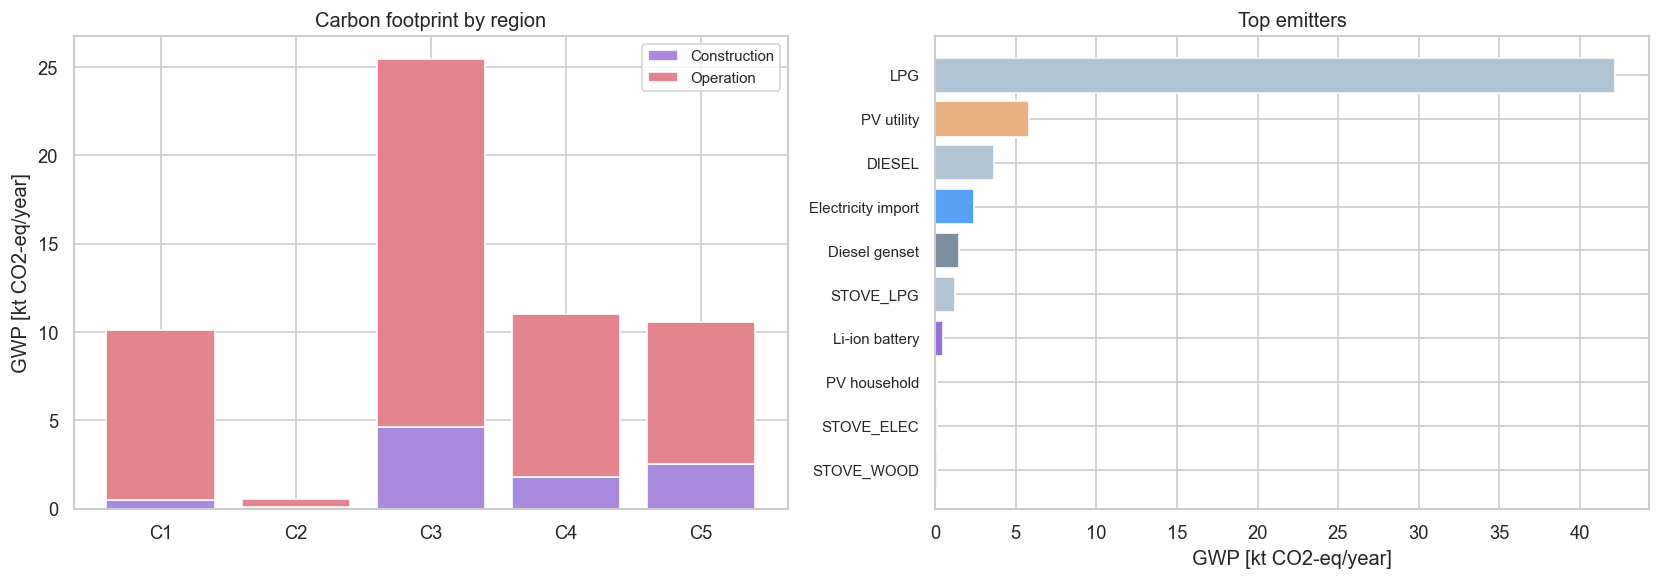

GWP operationnel total : 48.18 kt CO2-eq/year
Intensite electrique   : 338.1 g CO2/kWh produit


In [88]:
g = gwp_reg[gwp_reg['Regions'].isin(REGIONS)].copy()
for col in ['GWP_constr', 'GWP_op', 'CO2_net']:
    g[col] = g[col].fillna(0)
by_reg = g.groupby('Regions')[['GWP_constr', 'GWP_op']].sum().reindex(REGIONS).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- (a) GWP construction vs operation by region ----------------------------
ax = axes[0]
x = np.arange(len(REGIONS)); bottom = np.zeros(len(REGIONS))
for col, color, lab in [('GWP_constr', "#A98ADE", 'Construction'), ('GWP_op', "#E4848F", 'Operation')]:
    ax.bar(x, by_reg[col].values, bottom=bottom, color=color, label=lab, edgecolor='white')
    bottom += by_reg[col].values
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('GWP [kt CO2-eq/year]'); ax.set_title('Carbon footprint by region'); ax.legend(fontsize=9)

# -- (b) top emitters -------------------------------------------------------
ax = axes[1]
g['tot'] = g['GWP_constr'] + g['GWP_op']
top = g.groupby('Elements')['tot'].sum().sort_values(ascending=False).head(10)
top = top[top > EPS]
if len(top):
    ax.barh(range(len(top)), top.values[::-1], color=[get_color(t) for t in top.index[::-1]], edgecolor='white')
    ax.set_yticks(range(len(top))); ax.set_yticklabels([get_label(t) for t in top.index[::-1]], fontsize=9)
    ax.set_xlabel('GWP [kt CO2-eq/year]'); ax.set_title('Top emitters')
else:
    ax.text(0.5, 0.5, 'Negligible emissions', ha='center', va='center')
plt.tight_layout(); plt.show()

elec_total = elec_supply(yb, REGIONS)['val'].sum()
co2_op = g['GWP_op'].sum()
print(f'GWP operationnel total : {co2_op:.2f} kt CO2-eq/year')
print(f'Intensite electrique   : {co2_op/elec_total*1000:.1f} g CO2/kWh produit')

---
## 7. Storage

Deployed storage assets (capacity `F`, annual cycled energy) and average **state-of-charge profile** over the day (Li-ion battery).

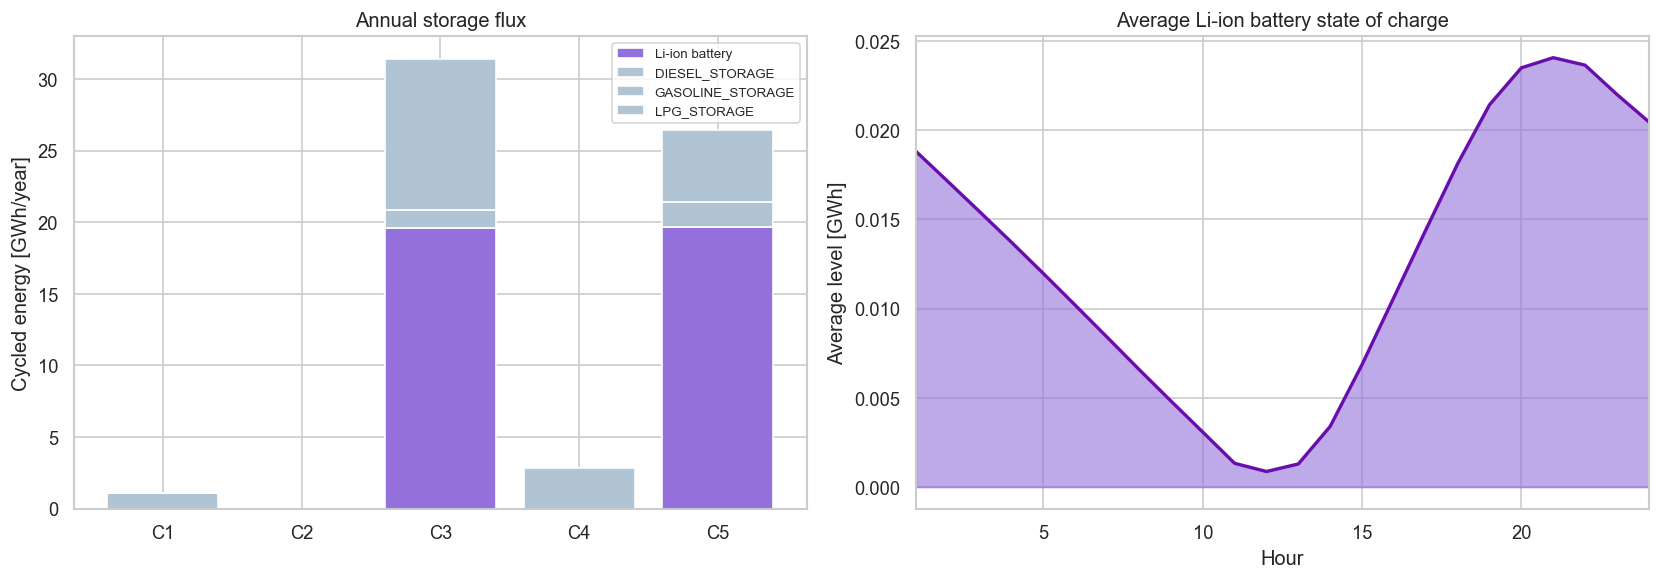

Active storage assets:
Regions     Technologies      F  Year_energy_flux  Losses
     C1   DIESEL_STORAGE  3.916             1.111     NaN
     C1 GASOLINE_STORAGE  3.651               NaN     NaN
     C3          BATT_LI    NaN            19.620  -2.177
     C3   DIESEL_STORAGE 19.278             1.194     NaN
     C3 GASOLINE_STORAGE 17.845               NaN     NaN
     C3      LPG_STORAGE  4.835            10.598     NaN
     C4   DIESEL_STORAGE  7.535               NaN     NaN
     C4 GASOLINE_STORAGE  6.975               NaN     NaN
     C4      LPG_STORAGE  1.675             2.800     NaN
     C5          BATT_LI    NaN            19.679  -2.184
     C5   DIESEL_STORAGE  7.445             1.713     NaN
     C5 GASOLINE_STORAGE  6.892               NaN     NaN
     C5      LPG_STORAGE  1.977             5.028     NaN


In [89]:
s = sto_reg[sto_reg['Regions'].isin(REGIONS)].copy()
s_act = s[s[['F', 'Year_energy_flux']].abs().max(axis=1) > EPS]

if s_act.empty:
    print('No active storage asset.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # -- (a) energy cycled by region / technology ---------------------------
    ax = axes[0]
    piv = s_act.pivot_table(index='Regions', columns='Technologies', values='Year_energy_flux',
                            aggfunc='sum', fill_value=0).reindex(REGIONS).fillna(0)
    x = np.arange(len(REGIONS)); bottom = np.zeros(len(REGIONS))
    for tech in piv.columns:
        ax.bar(x, piv[tech].values, bottom=bottom, label=get_label(tech), color=get_color(tech), edgecolor='white')
        bottom += piv[tech].values
    ax.set_xticks(x); ax.set_xticklabels(REGIONS)
    ax.set_ylabel('Cycled energy [GWh/year]'); ax.set_title('Annual storage flux'); ax.legend(fontsize=8)

    # -- (b) average state-of-charge profile (Storage_level) ---------------
    ax = axes[1]
    try:
        sl = pd.read_csv(HOURLY / 'Storage_level.csv', sep=';')
        sl['Storage_level'] = pd.to_numeric(sl['Storage_level'], errors='coerce').fillna(0)
        batt = sl[sl['Storage_tech'] == 'BATT_LI']
        if batt['Storage_level'].abs().sum() > EPS:
            batt = batt.copy(); batt['hour'] = (batt['Periods'] - 1) % 24 + 1
            prof = batt.groupby('hour')['Storage_level'].mean()
            ax.fill_between(prof.index, prof.values, color='#9370DB', alpha=.6)
            ax.plot(prof.index, prof.values, color='#6A0DAD', lw=2)
            ax.set_xlabel('Hour'); ax.set_ylabel('Average level [GWh]')
            ax.set_title('Average Li-ion battery state of charge'); ax.set_xlim(1, 24)
        else:
            ax.text(0.5, 0.5, 'Li-ion battery inactive', ha='center', va='center')
    except FileNotFoundError:
        ax.text(0.5, 0.5, 'Storage_level.csv not found', ha='center', va='center')
    plt.tight_layout(); plt.show()

    print('Active storage assets:')
    print(s_act[['Regions', 'Technologies', 'F', 'Year_energy_flux', 'Losses']].round(3).to_string(index=False))

---
## 8. Curtailment & flexibility

Available renewable energy that is **not used**. Low curtailment indicates well-sized flexibility (storage); high curtailment signals poorly valorised solar surplus.

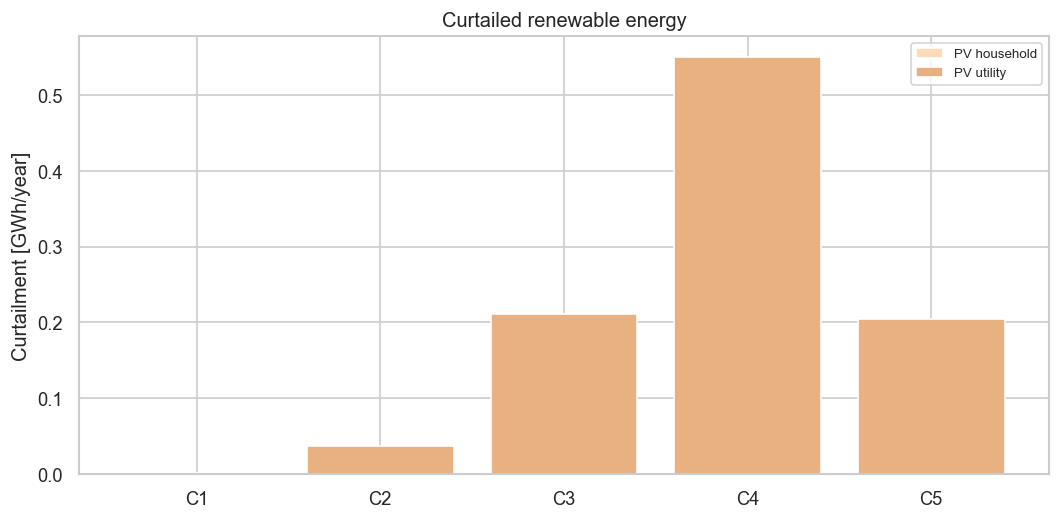

Curtailment total : 1.004 GWh/year
Taux global       : 0.78 % of renewable potential
Regions Technologies   Curt
     C1   PV_UTILITY 0.0021
     C1        PV_HS 0.0000
     C2   PV_UTILITY 0.0370
     C2        PV_HS 0.0000
     C3        PV_HS 0.0000
     C3   PV_UTILITY 0.2108
     C4        PV_HS 0.0000
     C4   PV_UTILITY 0.5499
     C5        PV_HS 0.0001
     C5   PV_UTILITY 0.2039


In [90]:
cu = curt_reg[curt_reg['Regions'].isin(REGIONS)].copy()
cu = cu[cu['Curt'] > EPS]
es = elec_supply(yb, REGIONS)

if cu.empty:
    print('OK Curtailment negligible - all renewable production is valorised.')
else:
    piv = cu.pivot_table(index='Regions', columns='Technologies', values='Curt', aggfunc='sum', fill_value=0).reindex(REGIONS).fillna(0)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(len(REGIONS)); bottom = np.zeros(len(REGIONS))
    for tech in piv.columns:
        ax.bar(x, piv[tech].values, bottom=bottom, label=get_label(tech), color=get_color(tech), edgecolor='white')
        bottom += piv[tech].values
    ax.set_xticks(x); ax.set_xticklabels(REGIONS)
    ax.set_ylabel('Curtailment [GWh/year]'); ax.set_title('Curtailed renewable energy'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    prod_renew = es[es['Elements'].isin(RENEW_ELEC)]['val'].sum()
    tot_curt = cu['Curt'].sum()
    print(f'Curtailment total : {tot_curt:.3f} GWh/year')
    print(f'Taux global       : {tot_curt/(tot_curt+prod_renew)*100:.2f} % of renewable potential')
    print(cu[['Regions', 'Technologies', 'Curt']].round(4).to_string(index=False))

---
## 9. Inter-regional exchanges

Annual flows exchanged between cells (power lines, fuel transport). Reveals regional specialisation and potential hub roles.

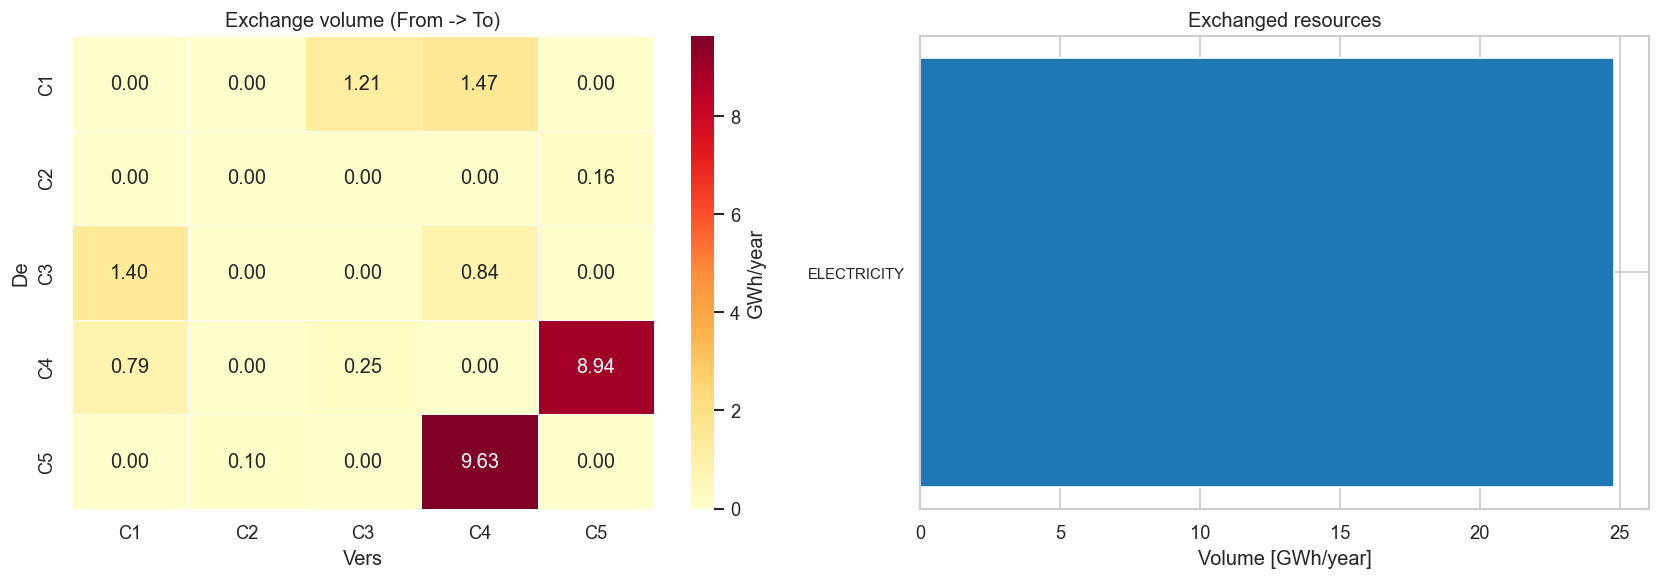

From To   Resources  Exchanges_year
  C1 C3 ELECTRICITY           1.207
  C1 C4 ELECTRICITY           1.474
  C2 C4 ELECTRICITY           0.003
  C2 C5 ELECTRICITY           0.165
  C3 C1 ELECTRICITY           1.403
  C3 C4 ELECTRICITY           0.845
  C4 C1 ELECTRICITY           0.792
  C4 C3 ELECTRICITY           0.249
  C4 C5 ELECTRICITY           8.937
  C5 C2 ELECTRICITY           0.104
  C5 C4 ELECTRICITY           9.626


In [91]:
e = exch_reg.copy()
e['Exchanges_year'] = e['Exchanges_year'].fillna(0)
cross = e[(e['From'].isin(REGIONS)) & (e['To'].isin(REGIONS)) &
          (e['From'] != e['To']) & (e['Exchanges_year'].abs() > EPS)]

if cross.empty:
    print('No significant inter-regional exchange (near-isolated cells).')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    mat = cross.groupby(['From', 'To'])['Exchanges_year'].sum().unstack(fill_value=0).reindex(index=REGIONS, columns=REGIONS, fill_value=0)
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=.5, cbar_kws={'label': 'GWh/year'})
    ax.set_title('Exchange volume (From -> To)'); ax.set_xlabel('Vers'); ax.set_ylabel('De')
    ax = axes[1]
    byres = cross.groupby('Resources')['Exchanges_year'].sum().sort_values(ascending=True)
    byres = byres[byres.abs() > EPS]
    ax.barh(range(len(byres)), byres.values, color=sns.color_palette('tab10', len(byres)))
    ax.set_yticks(range(len(byres))); ax.set_yticklabels(byres.index, fontsize=9)
    ax.set_xlabel('Volume [GWh/year]'); ax.set_title('Exchanged resources')
    plt.tight_layout(); plt.show()
    print(cross[['From', 'To', 'Resources', 'Exchanges_year']].round(3).to_string(index=False))

---
## 10. Hourly profiles - electric dispatch vs demand

EnergyScope represente l'annee par **16 journees typiques**. On superpose ici la **production** (empilee par techno) et la **demande electrique** (courbe noire) pour visualiser comment l'offre suit la charge, journee typique par journee typique.

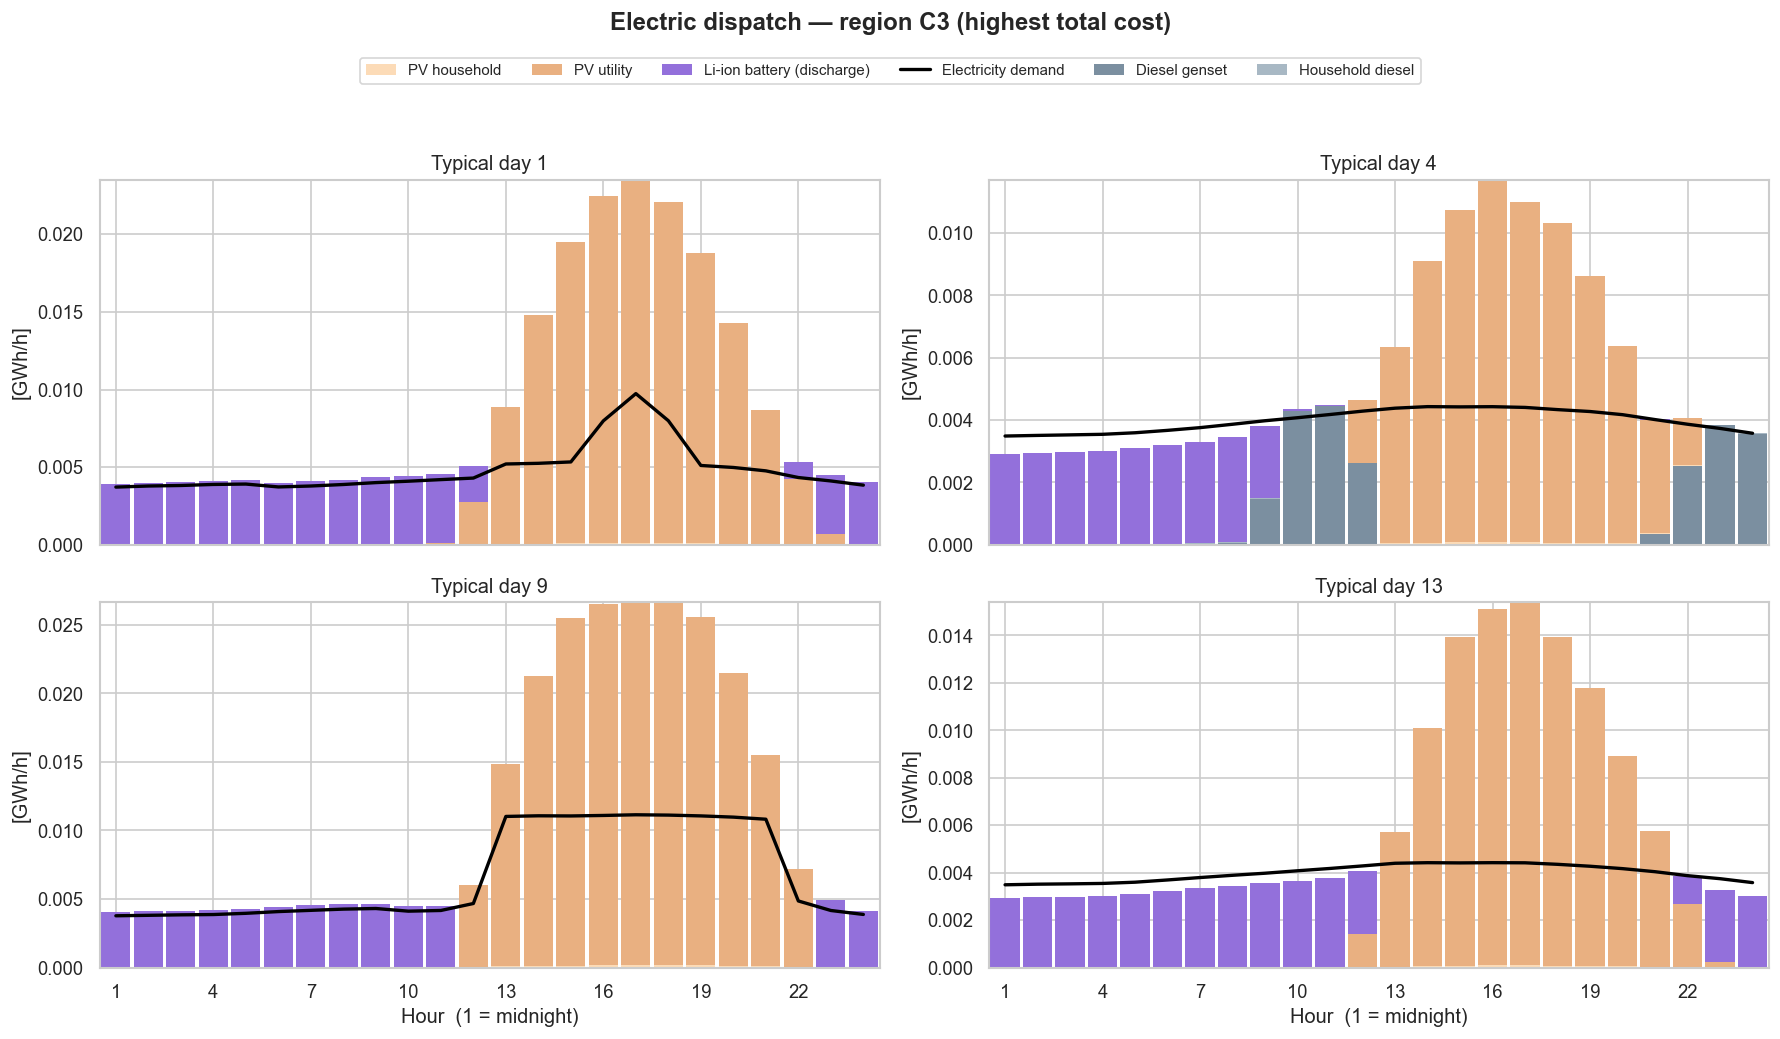

Region : C3  |  Typical days shown : [1, 4, 9, 13]
Generator techs in year balance : ['GENSET_DIESEL', 'HS_DIESEL', 'PV_HS', 'PV_UTILITY']
Active electricity consumers : ['AGR_MACHINERY_EL', 'ATM_CCS', 'BIOMASS_TO_HVC', 'BOAT_FREIGHT_ELEC', 'BUS_ELEC_PRIVATE', 'BUS_ELEC_PUBLIC', 'CARGO_FUELCELL_LH2', 'CARGO_MOTORCYCLE_ELEC', 'CAR_BEV', 'CAR_PHEV', 'COMM_MACHINERY_EL', 'CONVENTIONAL_BULB', 'CONVENTIONAL_LIGHT', 'DEC_DIRECT_ELEC', 'DEC_ELEC_COLD', 'DEC_HP_ELEC', 'DHN_HP_ELEC', 'FISH_MACHINERY_EL', 'GAS_TO_HVC', 'H2_ELECTROLYSIS', 'H2_TO_JET_FUEL', 'H2_TO_LFO', 'HABER_BOSCH', 'INDUSTRY_CCS', 'IND_DIRECT_ELEC', 'IND_ELEC_COLD', 'IND_MACHINERY_EL', 'LED_BULB', 'LED_LIGHT', 'MIN_MACHINERY_EL', 'MOTORCYCLE_ELEC_PRIVATE', 'MOTORCYCLE_ELEC_PUBLIC', 'OIL_TO_HVC', 'PICKUP_TRUCK_ELEC_PRIVATE', 'PICKUP_TRUCK_ELEC_PUBLIC', 'POWER_TO_JET_FUEL', 'POWER_TO_LFO', 'REFRIGERATOR_EL', 'STOVE_ELEC', 'SUV_ELEC_PRIVATE', 'SUV_ELEC_PUBLIC', 'SYN_METHANOLATION', 'TRACTOR_EL', 'TRAIN_FREIGHT_ELEC', 'TRAIN_PUB', 

In [92]:
# ── Load hourly data ────────────────────────────────────────────────────────
ft = pd.read_csv(HOURLY / 'F_t.csv', sep=';')
ft['F_t'] = pd.to_numeric(ft['F_t'], errors='coerce').fillna(0)

# Storage_power.csv: Storage_out >= 0 (discharge), Storage_in <= 0 (charge)
sp = pd.read_csv(HOURLY / 'Storage_power.csv', sep=';')
sp['Storage_out'] = pd.to_numeric(sp['Storage_out'], errors='coerce').fillna(0)
sp['Storage_in']  = pd.to_numeric(sp['Storage_in'],  errors='coerce').fillna(0)

# R_t_exterior.csv: hourly resource imports from outside the cell
rt_ext = pd.read_csv(HOURLY / 'R_t_exterior.csv', sep=';')
rt_ext['R_t_exterior'] = pd.to_numeric(rt_ext['R_t_exterior'], errors='coerce').fillna(0)

# Layers_in_out: electricity consumers (coef < 0) → |coef| used to weight F_t
lio = pd.read_csv('Data/2025/00_INDEP/Layers_in_out.csv', sep=';', index_col=0)
elec_consumer_coef = lio[lio['ELECTRICITY'] < 0]['ELECTRICITY'].abs()
active_consumers = elec_consumer_coef.index.intersection(ft['Technologies'].unique())

REGION_ANALYSE = total_cost.sort_values('TotalCost', ascending=False).iloc[0]['Regions']
HOURS = list(range(1, 25))

# Generators that produce electricity (from year balance, no imports, no storage)
gen_techs = set(elec_supply(yb, REGIONS)['Elements']) - IMPORT_ELEC

diesel_tds = sorted(
    ft[(ft['Regions'] == REGION_ANALYSE) & (ft['Technologies'] == 'GENSET_DIESEL') & (ft['F_t'] > EPS)]
    ['Typical_days'].unique().tolist()
)
TD_SHOW = [1, 5, 9, 13]
if diesel_tds and not any(td in diesel_tds for td in TD_SHOW):
    TD_SHOW[1] = diesel_tds[0]

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
all_handles = {}

for ax, td in zip(axes.ravel(), TD_SHOW):
    # ── Generators ──────────────────────────────────────────────────────────
    mask_gen = ((ft['Regions'] == REGION_ANALYSE) & (ft['Typical_days'] == td)
                & ft['Technologies'].isin(gen_techs) & (ft['F_t'] > EPS))
    gen = (ft[mask_gen]
           .pivot_table(index='Hours', columns='Technologies', values='F_t', aggfunc='sum', fill_value=0)
           .reindex(HOURS, fill_value=0))

    # ── SIN electricity import (R_t_exterior, resource ELECTRICITY) ──────────
    elec_imp = (rt_ext[(rt_ext['Regions'] == REGION_ANALYSE) & (rt_ext['Typical_days'] == td)
                        & (rt_ext['Resources'] == 'ELECTRICITY')]
                .set_index('Hours')['R_t_exterior']
                .reindex(HOURS, fill_value=0))

    # ── Li-ion battery discharge ──────────────────────────────────────────────
    batt = (sp[(sp['Regions'] == REGION_ANALYSE) & (sp['Typical_days'] == td)
               & (sp['Storage_tech'] == 'BATT_LI')]
            .set_index('Hours'))
    batt_dis = batt['Storage_out'].reindex(HOURS, fill_value=0)

    # ── Stacked bars (generators → SIN import → battery discharge) ───────────
    bottom = np.zeros(len(HOURS))
    for tech in gen.columns:
        h = ax.bar(HOURS, gen[tech].values, bottom=bottom, color=get_color(tech), width=0.9, edgecolor='none')
        bottom += gen[tech].values
        all_handles.setdefault(get_label(tech), h[0])

    if elec_imp.sum() > EPS:
        h = ax.bar(HOURS, elec_imp.values, bottom=bottom, color=get_color('ELECTRICITY'), width=0.9, edgecolor='none')
        bottom += elec_imp.values
        all_handles.setdefault('Electricity import (SIN)', h[0])

    if batt_dis.sum() > EPS:
        h = ax.bar(HOURS, batt_dis.values, bottom=bottom, color=get_color('BATT_LI'), width=0.9, edgecolor='none')
        bottom += batt_dis.values
        all_handles.setdefault('Li-ion battery (discharge)', h[0])

    # ── Exogenous demand line (sum of consumer F_t × |Layers_in_out| coef) ───
    # Independent of supply — verifies supply ≥ demand at every hour.
    # Gap between bars and line = battery charging at that hour (excess PV stored).
    mask_dem = ((ft['Regions'] == REGION_ANALYSE) & (ft['Typical_days'] == td)
                & ft['Technologies'].isin(active_consumers))
    dem_df = ft[mask_dem].copy()
    dem_df['contrib'] = dem_df['F_t'] * dem_df['Technologies'].map(elec_consumer_coef.to_dict())
    demand = dem_df.groupby('Hours')['contrib'].sum().reindex(HOURS, fill_value=0)
    line, = ax.plot(HOURS, demand.values, color='black', lw=2)
    all_handles.setdefault('Electricity demand', line)

    ax.set_title(f'Typical day {td}')
    ax.set_xlim(0.5, 24.5)
    ax.set_xticks(range(1, 25, 3))
    ax.set_ylabel('[GWh/h]')

for ax in axes[1, :]:
    ax.set_xlabel('Hour  (1 = midnight)')

fig.legend(all_handles.values(), all_handles.keys(),
           loc='upper center', ncol=min(6, len(all_handles)), fontsize=9, bbox_to_anchor=(0.5, 1.04))
plt.suptitle(f'Electric dispatch — region {REGION_ANALYSE} (highest total cost)', y=1.08, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Region : {REGION_ANALYSE}  |  Typical days shown : {TD_SHOW}')
print(f'Generator techs in year balance : {sorted(gen_techs)}')
print(f'Active electricity consumers : {sorted(active_consumers)}')
if diesel_tds:
    print(f'GENSET_DIESEL active in TDs : {diesel_tds}')

---
## 11. Summary

Summary table for the scenario and reading guide for the thesis write-up.

In [93]:
es = elec_supply(yb, REGIONS)
dem = eud_demand(yb, REGIONS)
elec_total = es['val'].sum()
elec_renew = es[es['Elements'].isin(RENEW_ELEC)]['val'].sum()
elec_imp = es[es['Elements'].isin(IMPORT_ELEC)]['val'].sum()

line = '=' * 64
print(line); print(f'  SUMMARY - {SCENARIO}'); print(line)
print(f'  Cout total systeme         : {total_cost["TotalCost"].sum():>8.2f} M€/year')
print(f'  Demande utile servie       : {dem.values.sum():>8.1f} GWh/year')
print(f'  Cout moyen                 : {total_cost["TotalCost"].sum()*1000/dem.values.sum():>8.1f} EUR/MWh utile')
print(f'  Production electrique      : {elec_total:>8.1f} GWh/year')
print(f'     dont renouvelable local : {elec_renew/elec_total*100:>8.1f} %')
print(f'     dont importee           : {elec_imp/elec_total*100:>8.1f} %')
print(f'  Emissions CO2 (op.)        : {gwp_reg["GWP_op"].fillna(0).sum():>8.2f} kt/year')
print('-' * 64)
print('  Dominant use by region   :')
for rg in REGIONS:
    top_use = dem.loc[rg].idxmax()
    print(f'    {rg} : demand {dem.loc[rg].sum():6.1f} GWh  .  top use = {eud_label(top_use)} ({dem.loc[rg].max():.1f} GWh)')
print(line)

print('''
READING GUIDE FOR THE THESIS
  1. Demande    : quels usages dominent (cuisson ? refrigeration ?) et pourquoi
                  (climat amazonien, sufficiency vs reality) ?
  2. Supply     : why does PV dominate? what role for diesel / imports?
  3. Autonomy   : which regions depend most on external supply?
  4. Cout       : pourquoi la region la plus chere l est-elle (demande, ressource,
                  isolement) ?
  5. Robustesse : quelles technologies apparaissent dans TOUS les scenarios
                  (no-regret) vs sensibles a la demande ? -> rejouer ce notebook
                  avec SCENARIO = reality et comparer.''')

  SUMMARY - norte_amazonia_sufficiency_2025
  Cout total systeme         :    24.18 M€/year
  Demande utile servie       :    187.3 GWh/year
  Cout moyen                 :    129.1 EUR/MWh utile
  Production electrique      :    142.5 GWh/year
     dont renouvelable local :     89.3 %
     dont importee           :      9.1 %
  Emissions CO2 (op.)        :    48.18 kt/year
----------------------------------------------------------------
  Dominant use by region   :
    C1 : demand   24.8 GWh  .  top use = Cooking (14.4 GWh)
    C2 : demand    1.9 GWh  .  top use = Cooking (1.1 GWh)
    C3 : demand   85.1 GWh  .  top use = Cooking (53.2 GWh)
    C4 : demand   38.5 GWh  .  top use = Cooking (22.0 GWh)
    C5 : demand   37.0 GWh  .  top use = Cooking (20.3 GWh)

READING GUIDE FOR THE THESIS
  1. Demande    : quels usages dominent (cuisson ? refrigeration ?) et pourquoi
                  (climat amazonien, sufficiency vs reality) ?
  2. Supply     : why does PV dominate? what role for dies

---
## 12. Phase 1 vs Phase 2 comparison

Direct comparison between **`norte_amazonia_sufficiency_2025`** (phase 1) et **`norte_amazonia_sufficiency_2025_phase2`** (phase 2) sur les indicateurs clés : demande, mix electrique, couts, empreinte carbone.

In [94]:
# -- Load both scenarios ----------------------------------------------------
D1 = load_scenario(BASE)
D2 = load_scenario(BASE_2)

SCEN_LABELS = {SCENARIO: 'Phase 1', SCENARIO_2: 'Phase 2'}
COLOR_P1 = '#5A9AE3'
COLOR_P2 = '#E4848F'

def kpis(D, scen):
    yb_   = D['yb'];  tc = D['total_cost']; tc = tc[tc['Regions'].isin(REGIONS)]
    es_   = elec_supply(yb_, REGIONS)
    dem_  = eud_demand(yb_, REGIONS)
    gwp_  = D['gwp']
    elec_tot  = es_['val'].sum()
    elec_renew = es_[es_['Elements'].isin(RENEW_ELEC)]['val'].sum()
    elec_imp   = es_[es_['Elements'].isin(IMPORT_ELEC)]['val'].sum()
    cost_tot   = tc['TotalCost'].sum()
    demand_tot = dem_.values.sum()
    co2_op     = pd.to_numeric(gwp_['GWP_op'], errors='coerce').fillna(0).sum()
    n_tech     = (D['assets'][D['assets']['F'] > EPS])['Technologies'].nunique()
    return {
        'Scenario':              SCEN_LABELS[scen],
        'Total cost (M€/year)':    round(cost_tot, 2),
        'Useful demand (GWh/year)':round(demand_tot, 1),
        'Average cost (€/MWh)':    round(cost_tot*1000/demand_tot, 1),
        'Elec. prod. (GWh/year)':  round(elec_tot, 1),
        'Renewable share (%)':          round(elec_renew/elec_tot*100, 1),
        'Elec. import share (%)': round(elec_imp/elec_tot*100, 1),
        'GWP op. (kt CO2/year)':   round(co2_op, 2),
        'Deployed techs':       n_tech,
    }

k1 = kpis(D1, SCENARIO)
k2 = kpis(D2, SCENARIO_2)
comp = pd.DataFrame([k1, k2]).set_index('Scenario').T
comp['Delta (P2-P1)'] = comp['Phase 2'] - comp['Phase 1']
comp['Delta (%)']     = (comp['Delta (P2-P1)'] / comp['Phase 1'].abs() * 100).round(1)
print('=' * 68)
print('  COMPARISON TABLE  Phase 1  vs  Phase 2')
print('=' * 68)
print(comp.to_string())
print('=' * 68)

  COMPARISON TABLE  Phase 1  vs  Phase 2
Scenario                  Phase 1  Phase 2  Delta (P2-P1)  Delta (%)
Total cost (M€/year)        23.78    24.18           0.40        1.7
Useful demand (GWh/year)   188.10   187.30          -0.80       -0.4
Average cost (€/MWh)       126.40   129.10           2.70        2.1
Elec. prod. (GWh/year)     144.00   142.50          -1.50       -1.0
Renewable share (%)         90.60    89.30          -1.30       -1.4
Elec. import share (%)       8.60     9.10           0.50        5.8
GWP op. (kt CO2/year)       46.69    48.18           1.49        3.2
Deployed techs              32.00    35.00           3.00        9.4


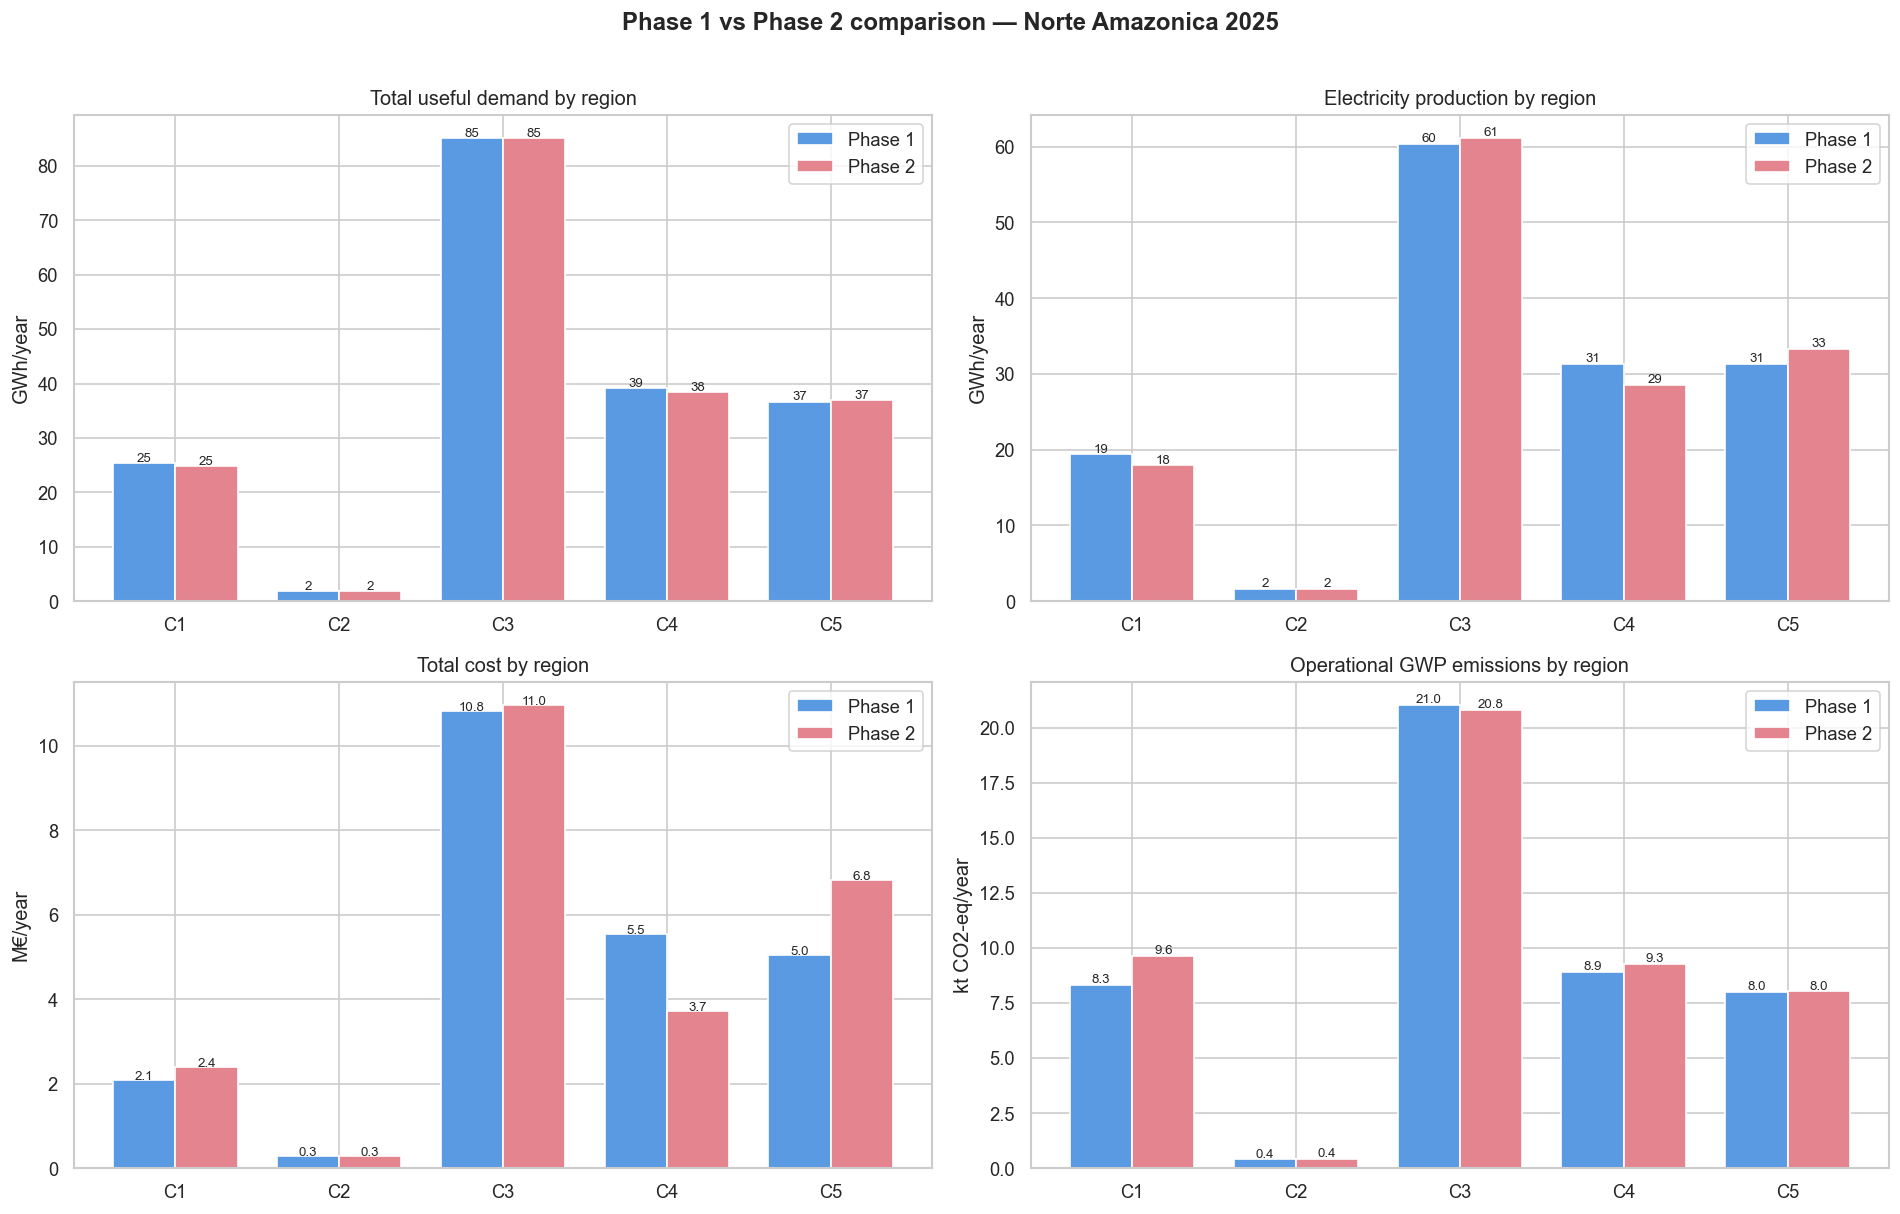

In [95]:
# -- Comparison charts ------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

x = np.arange(len(REGIONS)); w = 0.38

# (1) Demand by region
ax = axes[0, 0]
dem1 = eud_demand(D1['yb'], REGIONS).sum(axis=1).reindex(REGIONS).fillna(0)
dem2 = eud_demand(D2['yb'], REGIONS).sum(axis=1).reindex(REGIONS).fillna(0)
b1 = ax.bar(x - w/2, dem1.values, w, color=COLOR_P1, label='Phase 1', edgecolor='white')
b2 = ax.bar(x + w/2, dem2.values, w, color=COLOR_P2, label='Phase 2', edgecolor='white')
for b, v in zip(b1, dem1.values): ax.text(b.get_x()+b.get_width()/2, v+.3, f'{v:.0f}', ha='center', fontsize=8)
for b, v in zip(b2, dem2.values): ax.text(b.get_x()+b.get_width()/2, v+.3, f'{v:.0f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('GWh/year'); ax.set_title('Total useful demand by region'); ax.legend()

# (2) Electricity production by region
ax = axes[0, 1]
es1 = elec_supply(D1['yb'], REGIONS).groupby('Regions')['val'].sum().reindex(REGIONS).fillna(0)
es2 = elec_supply(D2['yb'], REGIONS).groupby('Regions')['val'].sum().reindex(REGIONS).fillna(0)
b1 = ax.bar(x - w/2, es1.values, w, color=COLOR_P1, label='Phase 1', edgecolor='white')
b2 = ax.bar(x + w/2, es2.values, w, color=COLOR_P2, label='Phase 2', edgecolor='white')
for b, v in zip(b1, es1.values): ax.text(b.get_x()+b.get_width()/2, v+.3, f'{v:.0f}', ha='center', fontsize=8)
for b, v in zip(b2, es2.values): ax.text(b.get_x()+b.get_width()/2, v+.3, f'{v:.0f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('GWh/year'); ax.set_title('Electricity production by region'); ax.legend()

# (3) Cost by region
ax = axes[1, 0]
c1 = D1['cost'][D1['cost']['Regions'].isin(REGIONS)].groupby('Regions')[['C_inv','C_maint','C_op']].sum().sum(axis=1).reindex(REGIONS).fillna(0)
c2 = D2['cost'][D2['cost']['Regions'].isin(REGIONS)].groupby('Regions')[['C_inv','C_maint','C_op']].sum().sum(axis=1).reindex(REGIONS).fillna(0)
b1 = ax.bar(x - w/2, c1.values, w, color=COLOR_P1, label='Phase 1', edgecolor='white')
b2 = ax.bar(x + w/2, c2.values, w, color=COLOR_P2, label='Phase 2', edgecolor='white')
for b, v in zip(b1, c1.values): ax.text(b.get_x()+b.get_width()/2, v+.01, f'{v:.1f}', ha='center', fontsize=8)
for b, v in zip(b2, c2.values): ax.text(b.get_x()+b.get_width()/2, v+.01, f'{v:.1f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('M€/year'); ax.set_title('Total cost by region'); ax.legend()

# (4) Operational GWP by region
ax = axes[1, 1]
g1 = D1['gwp'][D1['gwp']['Regions'].isin(REGIONS)].groupby('Regions')['GWP_op'].sum().reindex(REGIONS).fillna(0)
g2 = D2['gwp'][D2['gwp']['Regions'].isin(REGIONS)].groupby('Regions')['GWP_op'].sum().reindex(REGIONS).fillna(0)
b1 = ax.bar(x - w/2, g1.values, w, color=COLOR_P1, label='Phase 1', edgecolor='white')
b2 = ax.bar(x + w/2, g2.values, w, color=COLOR_P2, label='Phase 2', edgecolor='white')
for b, v in zip(b1, g1.values): ax.text(b.get_x()+b.get_width()/2, v+.1, f'{v:.1f}', ha='center', fontsize=8)
for b, v in zip(b2, g2.values): ax.text(b.get_x()+b.get_width()/2, v+.1, f'{v:.1f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('kt CO2-eq/year'); ax.set_title('Operational GWP emissions by region'); ax.legend()

plt.suptitle('Phase 1 vs Phase 2 comparison — Norte Amazonica 2025', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

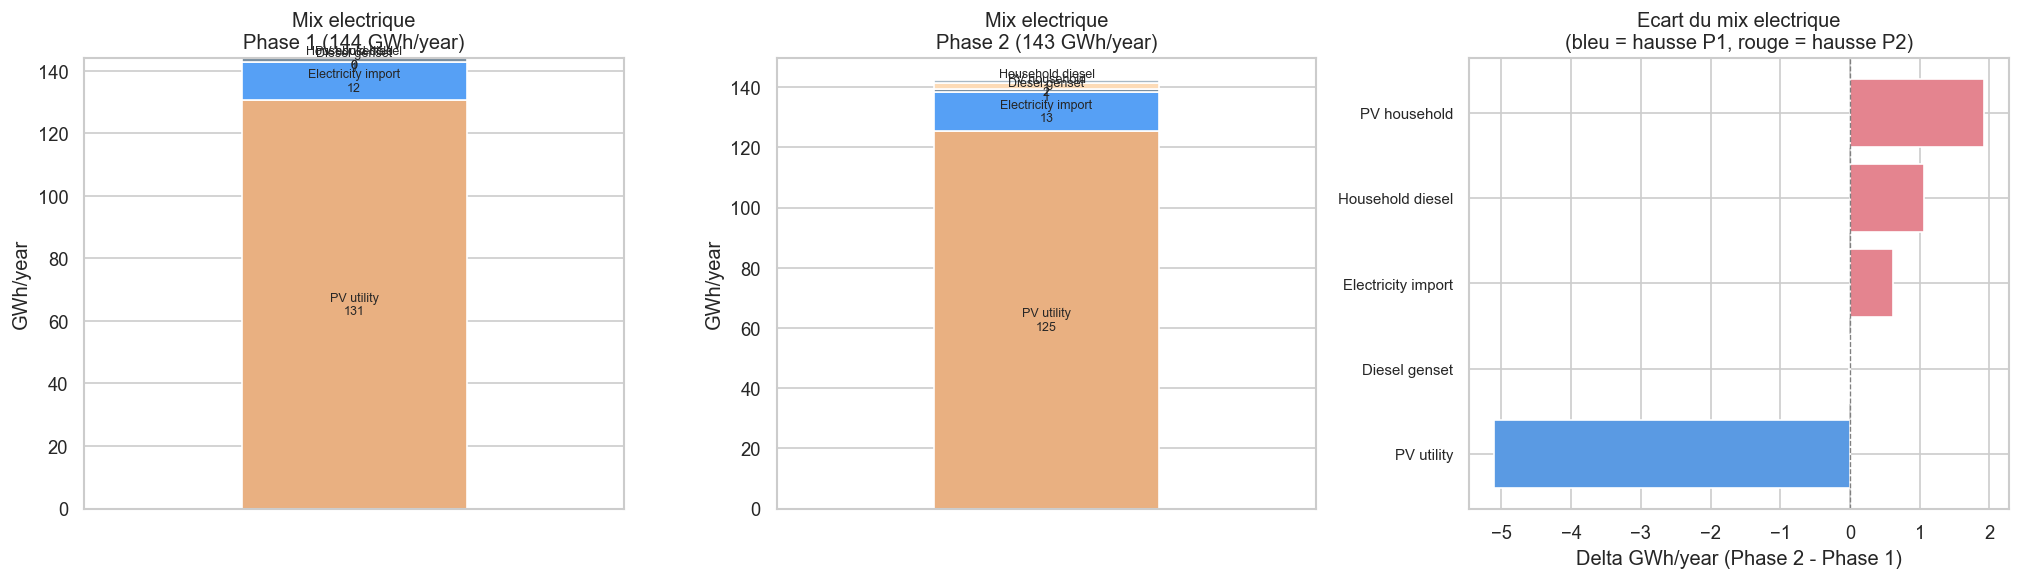

In [96]:
# -- Compared electricity mix (all regions aggregated) ----------------------
es1_all = elec_supply(D1['yb'], REGIONS)
es2_all = elec_supply(D2['yb'], REGIONS)

mix1 = es1_all.groupby('Elements')['val'].sum().sort_values(ascending=False)
mix2 = es2_all.groupby('Elements')['val'].sum().sort_values(ascending=False)
all_techs = sorted(set(mix1.index) | set(mix2.index), key=lambda t: -(mix1.get(t,0)+mix2.get(t,0)))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) stacked bars Phase 1
ax = axes[0]
bottom = 0
for t in all_techs:
    v = mix1.get(t, 0)
    if v > EPS:
        ax.bar(0, v, bottom=bottom, color=get_color(t), label=get_label(t), width=0.5)
        ax.text(0, bottom + v/2, f'{get_label(t)}\n{v:.0f}', ha='center', va='center', fontsize=7.5)
        bottom += v
ax.set_xlim(-0.6, 0.6); ax.set_xticks([]); ax.set_ylabel('GWh/year')
ax.set_title(f'Mix electrique\nPhase 1 ({mix1.sum():.0f} GWh/year)')

# (b) stacked bars Phase 2
ax = axes[1]
bottom = 0
for t in all_techs:
    v = mix2.get(t, 0)
    if v > EPS:
        ax.bar(0, v, bottom=bottom, color=get_color(t), label=get_label(t), width=0.5)
        ax.text(0, bottom + v/2, f'{get_label(t)}\n{v:.0f}', ha='center', va='center', fontsize=7.5)
        bottom += v
ax.set_xlim(-0.6, 0.6); ax.set_xticks([]); ax.set_ylabel('GWh/year')
ax.set_title(f'Mix electrique\nPhase 2 ({mix2.sum():.0f} GWh/year)')

# (c) delta (P2 - P1) by technology
ax = axes[2]
delta = {t: mix2.get(t,0) - mix1.get(t,0) for t in all_techs if abs(mix2.get(t,0)-mix1.get(t,0)) > EPS}
delta = dict(sorted(delta.items(), key=lambda kv: kv[1]))
cols = [COLOR_P2 if v > 0 else COLOR_P1 for v in delta.values()]
ax.barh(range(len(delta)), list(delta.values()), color=cols, edgecolor='white')
ax.set_yticks(range(len(delta)))
ax.set_yticklabels([get_label(t) for t in delta.keys()], fontsize=9)
ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel('Delta GWh/year (Phase 2 - Phase 1)')
ax.set_title('Ecart du mix electrique\n(bleu = hausse P1, rouge = hausse P2)')
plt.tight_layout(); plt.show()

CRF(10%, 30 years) = 0.10608

  GRID INFRASTRUCTURE  —  extension_capex_BC_EUR  (Phase 2 only)
  CRF annualisation (10% / 30 years) — consistent with EnergyScope
Region     CAPEX total (M€)  Annualise CRF (M€/an)
--------------------------------------------------------------
C1                   21.695                  2.301
C2                    2.937                  0.312
C3                   14.943                  1.585
C4                   26.171                  2.776
C5                    0.157                  0.017
--------------------------------------------------------------
TOTAL                65.903                  6.991


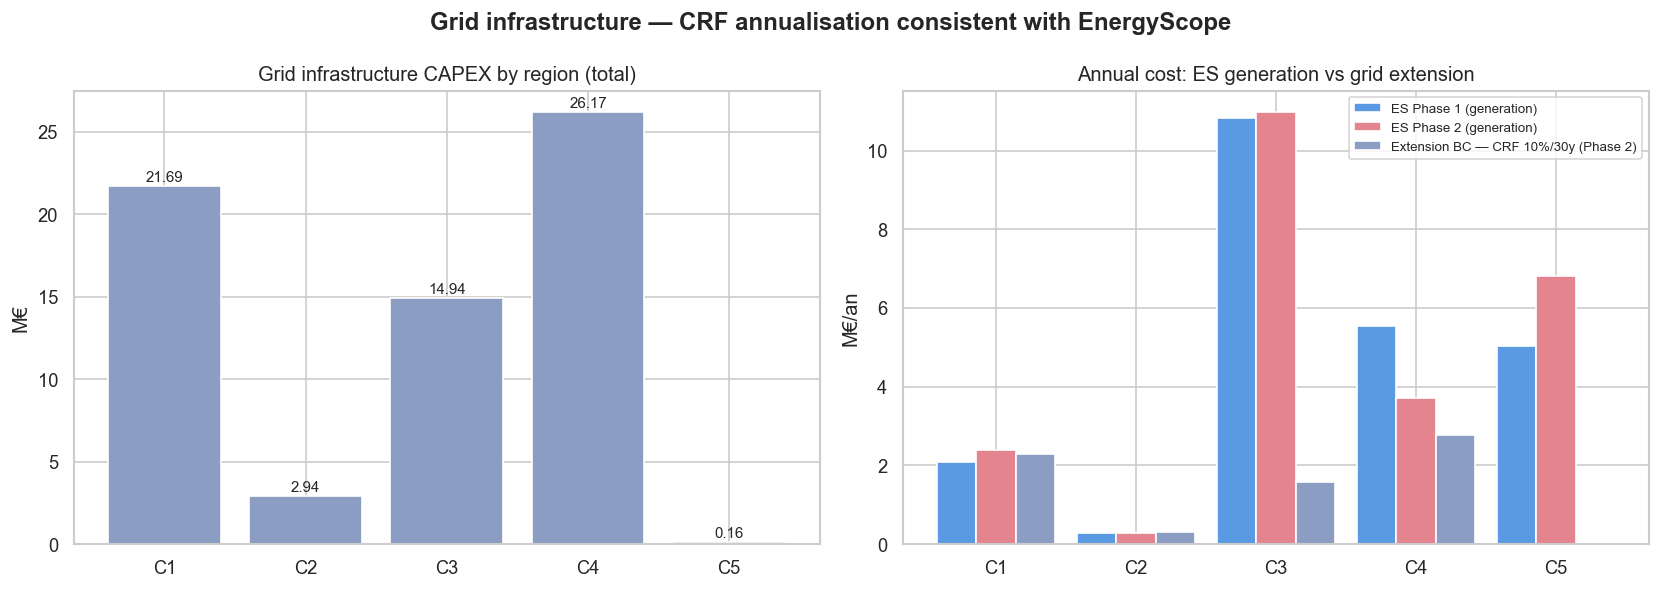


  TOTAL SYSTEM COST SUMMARY  (M€/year)
                                    Phase 1  Phase 2
------------------------------------------------------
  Generation (EnergyScope/CPLEX)     23.781   24.182
  Grid extension BC (CRF 10%/30y)     0.000    6.991
------------------------------------------------------
  TOTAL system cost                  23.781   31.173
  Delta  : +7.392 M€/year  (+31.1 %)


In [97]:
# -- Grid infrastructure (extension_capex_BC_EUR) ---------------------------
# Annualised using CRF consistent with EnergyScope (i=10%, n=30 years).
# This cost is specific to Phase 2 (connecting dispersed BC households).
# Phase 1 n'inclut pas ce deploiement → extension = 0.
I_RATE   = 0.10
LIFETIME = 30
CRF = I_RATE * (1 + I_RATE)**LIFETIME / ((1 + I_RATE)**LIFETIME - 1)

infra = pd.read_csv('Data/2025/share_dispersion_final_BC.csv')
infra = infra[infra['Cluster'].isin(REGIONS)].set_index('Cluster')

capex_bc   = infra['extension_capex_BC_EUR'] / 1e6   # M€ CAPEX total
annualized = capex_bc * CRF                           # M€/an (CRF)

print(f'CRF({I_RATE:.0%}, {LIFETIME} years) = {CRF:.5f}')
print()
print('=' * 62)
print('  GRID INFRASTRUCTURE  —  extension_capex_BC_EUR  (Phase 2 only)')
print(f'  CRF annualisation ({I_RATE:.0%} / {LIFETIME} years) — consistent with EnergyScope')
print('=' * 62)
print(f'{"Region":<8} {"CAPEX total (M€)":>18} {"Annualise CRF (M€/an)":>22}')
print('-' * 62)
for rg in REGIONS:
    print(f'{rg:<8} {capex_bc.get(rg, 0):>18.3f} {annualized.get(rg, 0):>22.3f}')
print('-' * 62)
print(f'{"TOTAL":<8} {capex_bc.sum():>18.3f} {annualized.sum():>22.3f}')
print('=' * 62)

# -- Graphique
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(REGIONS))

ax = axes[0]
bars = ax.bar(x, capex_bc.reindex(REGIONS).fillna(0).values, color='#8B9DC3', edgecolor='white')
for b, v in zip(bars, capex_bc.reindex(REGIONS).fillna(0).values):
    ax.text(b.get_x()+b.get_width()/2, v + capex_bc.max()*0.01, f'{v:.2f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('M€'); ax.set_title('Grid infrastructure CAPEX by region (total)')

ax = axes[1]
c1 = D1['cost'][D1['cost']['Regions'].isin(REGIONS)].groupby('Regions')[['C_inv','C_maint','C_op']].sum().sum(axis=1).reindex(REGIONS).fillna(0)
c2 = D2['cost'][D2['cost']['Regions'].isin(REGIONS)].groupby('Regions')[['C_inv','C_maint','C_op']].sum().sum(axis=1).reindex(REGIONS).fillna(0)
infra_ann = annualized.reindex(REGIONS).fillna(0)
w = 0.28
ax.bar(x - w,  c1.values,         w, color=COLOR_P1,  label='ES Phase 1 (generation)',           edgecolor='white')
ax.bar(x,      c2.values,         w, color=COLOR_P2,  label='ES Phase 2 (generation)',           edgecolor='white')
ax.bar(x + w,  infra_ann.values,  w, color='#8B9DC3', label=f'Extension BC — CRF {I_RATE:.0%}/{LIFETIME}y (Phase 2)', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('M€/an'); ax.set_title('Annual cost: ES generation vs grid extension')
ax.legend(fontsize=8)

plt.suptitle('Grid infrastructure — CRF annualisation consistent with EnergyScope', fontweight='bold')
plt.tight_layout(); plt.show()

# -- Corrected summary table
tot1_es = D1['total_cost'][D1['total_cost']['Regions'].isin(REGIONS)]['TotalCost'].sum()
tot2_es = D2['total_cost'][D2['total_cost']['Regions'].isin(REGIONS)]['TotalCost'].sum()
tot_infra_ann = annualized.sum()   # charged to Phase 2 only

tot1_sys = tot1_es                          # Phase 1 : pas d'extension BC
tot2_sys = tot2_es + tot_infra_ann          # Phase 2: generation + extension

delta_abs = tot2_sys - tot1_sys
delta_pct = delta_abs / tot1_sys * 100

line = '=' * 54
print(); print(line)
print('  TOTAL SYSTEM COST SUMMARY  (M€/year)')
print(line)
print(f'  {"":32s} {"Phase 1":>8} {"Phase 2":>8}')
print('-' * 54)
print(f'  {"Generation (EnergyScope/CPLEX)":32s} {tot1_es:>8.3f} {tot2_es:>8.3f}')
print(f'  {"Grid extension BC (CRF 10%/30y)":32s} {"0.000":>8} {tot_infra_ann:>8.3f}')
print('-' * 54)
print(f'  {"TOTAL system cost":32s} {tot1_sys:>8.3f} {tot2_sys:>8.3f}')
print(line)
print(f'  Delta  : {delta_abs:+.3f} M€/year  ({delta_pct:+.1f} %)')
print(line)